## Configurações, Imports e Funções

### Imports

In [6]:
import os
import re
import json
import math
import warnings
from glob import glob
from collections import defaultdict, Counter
import ast
import time
import joblib
import pickle

import pandas as pd
import numpy as np
from pandarallel import pandarallel

# Gensim
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.corpora import Dictionary

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

### Configurações

In [7]:
# Configurações
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore",
    message="Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated",
    category=FutureWarning
)
pandarallel.initialize(progress_bar=True)

# Constantes de configuração
RANDOM_STATE = 42
NUMERO_DE_TOPICOS = 5
WORDS_PER_TOPIC_FOR_DISPLAY = 8

# Caminhos dos arquivos
DATASET_PATH = './datasets/database-lemmetizado.csv.zip'
FILTERED_IPCR_PATH = './datasets/database-filtrado.csv.zip'
MODEL_ML_DIR = f'./modelos/ml/'
MODELS_DIR = f'./modelos/lda_por_ano/{NUMERO_DE_TOPICOS}_topics/'
RESULTS_DIR = f'./resultados_por_ano/{NUMERO_DE_TOPICOS}_topics/'
ANALYSIS_DIR = f'./resultados_analise/{NUMERO_DE_TOPICOS}_topics/'


INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


### Funções

#### Funções Auxiliares

In [8]:
def load_dataset(filepath, compression='zip'):
    """Carrega o dataset e prepara para processamento."""
    df = pd.read_csv(filepath, compression=compression)
    df = df.sort_values('date_published').reset_index(drop=True)
    df['date_published'] = pd.to_datetime(df['date_published'], errors='coerce')
    return df

def sample_reduce_by_year(df, keep_fraction=0.25, seed=42, year_col='year', min_per_year=1):
    """
    Retorna uma versão reduzida do DataFrame mantendo 'keep_fraction' das linhas
    de cada ano (ou seja, remove ~ (1 - keep_fraction) por ano).
    - keep_fraction: proporção a manter por ano (0 < keep_fraction <= 1). Padrão 0.25 (remove 75%).
    - seed: semente para reprodutibilidade.
    - year_col: nome da coluna com o ano.
    - min_per_year: garante pelo menos este número de linhas por ano.
    """
    if year_col not in df.columns:
        raise ValueError(f"Coluna '{year_col}' não encontrada no DataFrame.")
    if not (0 < keep_fraction <= 1):
        raise ValueError("keep_fraction deve ser > 0 e <= 1.")

    sampled_parts = []
    grouped = df.groupby(year_col)
    for _, g in grouped:
        k = max(min_per_year, int(round(len(g) * keep_fraction)))
        k = min(k, len(g))
        if k > 0:
            sampled_parts.append(g.sample(n=k, random_state=seed))

    if not sampled_parts:
        return pd.DataFrame(columns=df.columns)

    sampled = pd.concat(sampled_parts, ignore_index=False)
    sampled = sampled.sort_index()
    return sampled.reset_index(drop=True)

def tokenize_text(text):
    """Tokeniza o texto convertendo para minúsculas e separando por espaços."""
    return text.lower().split()


def prepare_corpus_and_dictionary(df, token_column='tokens'):
    """Prepara corpus e dicionário para modelagem LDA."""
    documents = df[token_column].dropna().astype(str).tolist()
    processed_docs = [tokenize_text(doc) for doc in documents]
    
    dictionary = corpora.Dictionary(processed_docs)
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
    
    return corpus, dictionary, processed_docs

In [9]:
'pd' in globals(), globals().get('pd')

(True,
 <module 'pandas' from 'c:\\Users\\luish\\Documentos\\Projetos\\artigo-rp2\\analise_patentes\\.venv\\Lib\\site-packages\\pandas\\__init__.py'>)

#### Funções de Treinamento do LDA

In [10]:
def train_and_save_lda_per_year(df, num_topics=10, passes=10, 
                                alpha='auto', eta='auto', output_dir=MODELS_DIR):
    """
    Treina um modelo LDA para cada ano e salva-o individualmente.
    
    Args:
        df: DataFrame com 'date_published' e 'tokens'
        num_topics: Número de tópicos para cada modelo
        passes: Número de passes de treinamento
        alpha: Parâmetro alpha do LDA
        eta: Parâmetro eta do LDA
        output_dir: Diretório para salvar os modelos
    """
    df['year'] = df['date_published'].dt.year
    years = sorted(df['year'].dropna().unique())
    
    print(f"Anos encontrados no dataset: {years}")
    
    os.makedirs(output_dir, exist_ok=True)
    print(f"Modelos serão salvos em: '{output_dir}'")
    
    models_trained_count = 0
    
    for year in years:
        print(f"\n=== Processando ano: {year} ===")
        
        df_year = df[df['year'] == year].copy()
        documents = df_year['tokens'].dropna().tolist()
        
        processed_docs = [
            doc.split() if isinstance(doc, str) else doc 
            for doc in documents
        ]
        processed_docs = [doc for doc in processed_docs if doc]
        
        print(f"Documentos para treinamento: {len(processed_docs)}")
        
        dictionary_year = corpora.Dictionary(processed_docs)
        corpus_year = [dictionary_year.doc2bow(doc) for doc in processed_docs]
        
        try:
            lda_model = models.LdaModel(
                corpus=corpus_year,
                id2word=dictionary_year,
                num_topics=num_topics,
                random_state=RANDOM_STATE,
                passes=passes,
                alpha=alpha,
                eta=eta
            )
            
            model_path = os.path.join(output_dir, f'lda_model_{year}.model')
            lda_model.save(model_path)
            
            print(f"Modelo salvo: '{model_path}'")
            models_trained_count += 1
            
        except Exception as e:
            print(f"ERRO ao treinar o modelo para o ano {year}: {e}")
            continue
    
    print(f"\n=== {models_trained_count} modelos treinados com sucesso ===")


def display_topics_from_models_with_probs(model_dir, plot_top_words=True, combine_topics_in_year=True, topics_per_row=3):
    """Exibe os tópicos de cada modelo LDA com probabilidades e plota gráficos."""
    if not os.path.exists(model_dir):
        print(f"ERRO: O diretório '{model_dir}' não foi encontrado.")
        return

    model_files = [
        f for f in os.listdir(model_dir) 
        if f.startswith('lda_model_') and f.endswith('.model')
    ]
    
    if not model_files:
        print(f"Nenhum modelo encontrado em '{model_dir}'.")
        return
    
    model_files.sort()
    print(f"Encontrados {len(model_files)} modelos.\n")
    
    for filename in model_files:
        try:
            match = re.search(r'_(\d{4})\.model', filename)
            if not match:
                continue
            
            year = match.group(1)
            model_path = os.path.join(model_dir, filename)
            lda_model = LdaModel.load(model_path)
            
            print(f"--- Tópicos para o Ano: {year} ---")
            
            topics = lda_model.show_topics(
                num_topics=-1, 
                num_words=WORDS_PER_TOPIC_FOR_DISPLAY, 
                formatted=False
            )
            
            # Exibe tópicos no console
            for topic_id, word_probs in topics:
                formatted_words = [
                    f"{word} ({prob*100:.2f}%)" 
                    for word, prob in word_probs
                ]
                print(f"Tópico {topic_id}: {', '.join(formatted_words)}")

            # Plota TODOS os tópicos do ano em UMA figura (grid) se solicitado
            if plot_top_words:
                try:
                    if combine_topics_in_year:
                        num_topics = len(topics)
                        if num_topics == 0:
                            continue
                        cols = min(topics_per_row, num_topics)
                        rows = math.ceil(num_topics / cols)
                        fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*2.5))
                        # normalize axes to a flat list
                        if isinstance(axes, np.ndarray):
                            axes_list = axes.flatten().tolist()
                        else:
                            axes_list = [axes]

                        for idx, (topic_id, word_probs) in enumerate(topics):
                            ax = axes_list[idx]
                            words = [w for w, p in word_probs]
                            probs = [p for w, p in word_probs]
                            words_plot = words[::-1]
                            probs_plot = probs[::-1]
                            y_pos = range(len(words_plot))
                            ax.barh(y_pos, probs_plot, color=f'C{idx % 10}')
                            ax.set_yticks(y_pos)
                            ax.set_yticklabels(words_plot, fontsize=9)
                            ax.set_xlabel('Probabilidade')
                            ax.set_title(f'Tópico {topic_id}')
                            ax.invert_yaxis()

                        # desliga eixos extras
                        for j in range(idx+1, len(axes_list)):
                            try:
                                axes_list[j].axis('off')
                            except Exception:
                                pass
                        plt.suptitle(f'Ano {year} — Top {WORDS_PER_TOPIC_FOR_DISPLAY} palavras por tópico', y=1.02)
                        plt.tight_layout()
                        plt.show()
                    else:
                        for topic_id, word_probs in topics:
                            try:
                                words = [w for w, p in word_probs]
                                probs = [p for w, p in word_probs]
                                words_plot = words[::-1]
                                probs_plot = probs[::-1]
                                plt.figure(figsize=(8, max(2, len(words_plot)*0.4)))
                                y_pos = range(len(words_plot))
                                plt.barh(y_pos, probs_plot, color='C0')
                                plt.yticks(y_pos, words_plot, fontsize=10)
                                plt.xlabel('Probabilidade')
                                plt.title(f'Ano {year} — Tópico {topic_id} (top {len(words)})')
                                plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
                                plt.gca().invert_yaxis()
                                plt.tight_layout()
                                plt.show()
                            except Exception as e:
                                print(f"ERRO plotando cada tópico por figura: {e}")
                except Exception as e:
                    print(f"ERRO plotando tópicos: {e}")
            print()
        except Exception as e:
            print(f"ERRO ao processar {filename}: {e}")

#### Funções de processamento de patentes

In [22]:
def _processar_patente(row, lda_model, dicionario, 
                      distribuicoes_topicos_ano, num_topics):
    """Processa uma única patente extraindo distribuição de tópicos."""
    # Ensure pandas (and json) are available inside worker processes
    import pandas as pd
    import json

    lens_id_final = row['lens_id']
    tokens_brutos = row['tokens']

    # filtros de tokens inválidos
    if pd.isna(tokens_brutos) or tokens_brutos == '':
        return None
    
    if isinstance(tokens_brutos, str):
        tokens_patente = tokens_brutos.split()
    elif isinstance(tokens_brutos, list):
        tokens_patente = tokens_brutos
    else:
        return None
    
    tokens_patente = [t for t in tokens_patente if t and isinstance(t, str)]
    
    if not tokens_patente:
        return None

    # distribuição de tópicos para a patente
    doc_bow = dicionario.doc2bow(tokens_patente)
    distribuicao_topicos_patente = lda_model.get_document_topics(
        doc_bow, minimum_probability=0.0
    )
    prob_topico_dado_doc = {
        topico_id: prob 
        for topico_id, prob in distribuicao_topicos_patente
    }

    resultado_patente = {
        'lens_id': lens_id_final, 
        'year': int(row['year'])
    }
    
    # calcula a pontuação das palavras por tópico
    for id_topico in range(num_topics):
        p_topico_na_patente = prob_topico_dado_doc.get(id_topico, 0)
        distribuicao_palavras_topico = distribuicoes_topicos_ano[id_topico]
        
        lista_pontuacao_palavras = []
        doc_bow_dict = dict(doc_bow)
        
        for id_palavra, p_palavra_no_topico in distribuicao_palavras_topico:
            if id_palavra in doc_bow_dict:
                pontuacao = float(p_topico_na_patente * p_palavra_no_topico)
                palavra_str = dicionario[id_palavra]
                lista_pontuacao_palavras.append((palavra_str, pontuacao))
        
        lista_pontuacao_palavras.sort(key=lambda item: item[1], reverse=True)
        top_palavras = lista_pontuacao_palavras[:50]
        
        resultado_patente[f'Topic_{id_topico}'] = json.dumps(
            top_palavras, ensure_ascii=False
        )
    
    return resultado_patente


#### Funções de Tratamento de Resultados

In [12]:
def concatenar_resultados_por_ano(diretorio_resultados, formato='csv'):
    """Concatena todos os arquivos de resultados em um único DataFrame."""
    if not os.path.exists(diretorio_resultados):
        raise ValueError(f"Diretório '{diretorio_resultados}' não encontrado!")
    
    padroes_formato = {
        'auto': ['resultados_*.csv', 'resultados_*.parquet'],
        'csv': ['resultados_*.csv'],
        'parquet': ['resultados_*.parquet']
    }
    
    padroes = padroes_formato.get(formato)
    if not padroes:
        raise ValueError("formato deve ser 'csv', 'parquet' ou 'auto'")
    
    arquivos = []
    for padrao in padroes:
        caminho_completo = os.path.join(diretorio_resultados, padrao)
        arquivos.extend(glob(caminho_completo))
    
    if not arquivos:
        print(f"⚠ Nenhum arquivo encontrado em '{diretorio_resultados}'")
        return pd.DataFrame()
    
    arquivos = sorted(set(arquivos))
    print(f"Encontrados {len(arquivos)} arquivos para concatenar")
    print(f"{'='*60}")
    
    dataframes_lista = []
    
    for arquivo in arquivos:
        try:
            nome_arquivo = os.path.basename(arquivo)
            
            if arquivo.endswith('.csv'):
                df_temp = pd.read_csv(arquivo)
                tipo = 'CSV'
            elif arquivo.endswith('.parquet'):
                df_temp = pd.read_parquet(arquivo)
                tipo = 'Parquet'
            else:
                continue
            
            dataframes_lista.append(df_temp)
            print(f"✓ {nome_arquivo} ({tipo}) - {len(df_temp)} registros")
            
        except Exception as e:
            print(f"✗ ERRO ao carregar {nome_arquivo}: {str(e)[:80]}")
            continue
    
    if not dataframes_lista:
        print("\n⚠ Nenhum DataFrame válido foi carregado!")
        return pd.DataFrame()
    
    print(f"\n{'='*60}")
    print(f"Concatenando {len(dataframes_lista)} DataFrames...")
    
    df_final = pd.concat(dataframes_lista, ignore_index=True)
    
    print("Concatenação concluída!")
    print(f"\nRESUMO DO DATASET FINAL:")
    print(f"{'='*60}")
    print(f" --- Total de registros: {len(df_final):,}")
    print(f" --- Total de colunas: {len(df_final.columns)}")
    print(f" --- Anos presentes: {sorted(df_final['year'].unique().tolist())}")
    print(f" --- Registros por ano:")
    
    contagem_por_ano = df_final['year'].value_counts().sort_index()
    for ano, contagem in contagem_por_ano.items():
        print(f"    - {ano}: {contagem:,} patentes")
    
    print(f"{'='*60}")
    
    return df_final


def converter_json_para_listas(df, prefixo_coluna='Topic_'):
    """Converte colunas JSON (strings) de volta para listas Python."""
    df_copia = df.copy()
    colunas_topicos = [
        col for col in df_copia.columns if col.startswith(prefixo_coluna)
    ]
    
    print(f"Convertendo {len(colunas_topicos)} colunas de tópicos...")
    
    for col in colunas_topicos:
        try:
            df_copia[col] = df_copia[col].apply(
                lambda x: json.loads(x) 
                if isinstance(x, str) and x.strip() != '[]' 
                else []
            )
        except Exception as e:
            print(f"⚠ Erro ao converter coluna {col}: {e}")
            continue
    
    print("Conversão concluída!")
    return df_copia

def _compute_dominant_topic(row, topic_cols):
    best_topic = None
    best_score = -1.0
    for col in topic_cols:
        lst = row.get(col, [])
        # lst esperado como lista de [palavra, score] ou (palavra, score)
        total = 0.0
        if isinstance(lst, str):
            try:
                lst = json.loads(lst)
            except Exception:
                lst = []
        if isinstance(lst, list):
            for item in lst:
                try:
                    score = float(item[1])
                except Exception:
                    score = 0.0
                total += score
        if total > best_score:
            best_score = total
            best_topic = col
    return best_topic

#### Funções de Análise de Similaridade

In [13]:
def clean_word_original(palavra_suja):
    """Limpa palavras removendo caracteres não-alfabéticos."""
    if isinstance(palavra_suja, str):
        palavra_limpa = re.sub(r"[^a-zA-Zá-úÁ-Ú]", "", palavra_suja)
        return palavra_limpa if palavra_limpa else None
    return None

# Analisa de forma a fazer a pergunta:
# Estas patentes têm as mesmas palavras (sem considerar seus pesos)?
def analise_similaridade_jaccard(df_completo, numero_palavras_por_topico, 
                                 percentual_similaridade, anos_a_frente=1):
    """Análise de similaridade usando coeficiente de Jaccard otimizado."""
    df_otimizado = df_completo.copy()
    topic_columns = [col for col in df_otimizado.columns if 'Topic_' in col]
    
    print("Iniciando extração vetorizada de palavras-chave...")

    # 'Melt' transforma colunas (Topic_1, Topic_2) em linhas
    df_melted = df_otimizado.melt(
        id_vars=['lens_id'], 
        value_vars=topic_columns, 
        value_name='topic_list'
    )
    
    df_melted = df_melted.dropna(subset=['topic_list'])

    # 'Explode' transforma listas em linhas
    # Se 'topic_list' era [['word1', 0.5], ['word2', 0.4]],
    # agora teremos duas linhas: ['word1', 0.5] e ['word2', 0.4]
    df_exploded = df_melted.explode('topic_list')
    
    df_exploded = df_exploded[
        df_exploded['topic_list'].apply(
            lambda x: isinstance(x, list) and len(x) > 0
        )
    ]
    
    df_exploded['palavra_suja'] = df_exploded['topic_list'].str[0]
    
    print("Limpando palavras-chave...")
    df_exploded['palavra_limpa'] = df_exploded['palavra_suja'].apply(
        clean_word_original
    )
    
    df_exploded = df_exploded.dropna(subset=['palavra_limpa'])

    # Agrupa por patente E por tópico de origem, e pega as N primeiras
    # Isso simula o '[:n_palavras]' da função original, para CADA tópico
    df_top_n = df_exploded.groupby(['lens_id', 'variable']).head(
        numero_palavras_por_topico
    )
    
    palavras_chave_series = df_top_n.groupby('lens_id')['palavra_limpa'].apply(set)
    df_otimizado['palavras_chave'] = df_otimizado['lens_id'].map(
        palavras_chave_series
    )
    df_otimizado['palavras_chave'] = df_otimizado['palavras_chave'].apply(
        lambda x: x if isinstance(x, set) else set()
    )
    
    print("Assinaturas de palavras criadas com sucesso.")
    
    print("\nIniciando comparação de similaridade otimizada...")
    
    resultados_finais = []
    anos_unicos = sorted(df_otimizado['year'].unique())
    
    for i in range(len(anos_unicos)):
        ano_atual = anos_unicos[i]
        
        # Verifica se há anos suficientes à frente
        if i + anos_a_frente >= len(anos_unicos):
            # Adiciona patentes do último ano(s) sem comparação
            df_ano_atual = df_otimizado[df_otimizado['year'] == ano_atual]
            for patente_atual in df_ano_atual.itertuples():
                resultados_finais.append({
                    'lens_id': patente_atual.lens_id,
                    'patentes_similares': []
                })
            continue
        
        # Coleta anos futuros para comparação
        anos_futuros = anos_unicos[i+1:i+1+anos_a_frente]
        print(f"Comparando ano {ano_atual} com anos {anos_futuros}...")
        
        df_ano_atual = df_otimizado[df_otimizado['year'] == ano_atual]
        df_anos_futuros = df_otimizado[df_otimizado['year'].isin(anos_futuros)]
        
        # Cria um mapa de lookup rápido para os anos futuros
        palavras_futuras_map = df_anos_futuros.set_index('lens_id')['palavras_chave']
        
        # Cria o Índice Invertido para os anos futuros
        inverted_index = defaultdict(set)
        for lens_id, palavras_set in palavras_futuras_map.items():
            for palavra in palavras_set:
                inverted_index[palavra].add(lens_id)

        # Itera sobre o ano atual        
        for patente_atual in df_ano_atual.itertuples():
            id_atual = patente_atual.lens_id
            palavras_atuais = patente_atual.palavras_chave
            len_atuais = len(palavras_atuais)
            
            if len_atuais == 0:
                resultados_finais.append({
                    'lens_id': id_atual,
                    'patentes_similares': []
                })
                continue
            
            # Encontra candidatos usando o Índice Invertido
            # 'candidate_counts' irá armazenar: {id_candidato -> contagem_de_palavras_em_comum}
            # A contagem de palavras em comum é exatamente o tamanho da INTERSEÇÃO
            candidate_counts = Counter()
            for palavra in palavras_atuais:
                candidate_counts.update(inverted_index[palavra])
                
            patentes_similares_encontradas = []

            for id_futuro, intersecao in candidate_counts.items():
                palavras_futuras = palavras_futuras_map[id_futuro]
                uniao = len_atuais + len(palavras_futuras) - intersecao
                
                similaridade = intersecao / uniao if uniao > 0 else 0
                
                if similaridade >= percentual_similaridade:
                    patentes_similares_encontradas.append(id_futuro)

            resultados_finais.append({
                'lens_id': id_atual,
                'patentes_similares': patentes_similares_encontradas
            })
    
    print("Comparação finalizada.")
    
    df_resultados = pd.DataFrame(resultados_finais)
    df_otimizado = pd.merge(df_otimizado, df_resultados, on='lens_id', how='left')
    
    df_otimizado['patentes_similares'] = df_otimizado['patentes_similares'].apply(
        lambda x: x if isinstance(x, list) else []
    )
    df_otimizado['count_similares'] = df_otimizado['patentes_similares'].apply(len)
    df_otimizado['emergente'] = df_otimizado['count_similares'] > 0
    
    print("\nResultado Final:")
    print(df_otimizado[['lens_id', 'year', 'patentes_similares', 
                        'count_similares', 'emergente']].head())
    
    os.makedirs(f'{ANALYSIS_DIR}', exist_ok=True)
    output_path = (
        f'{ANALYSIS_DIR}analise-de-similaridade_jaccard_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}_'
        f'anos{anos_a_frente}.csv'
    )
    df_otimizado.to_csv(output_path, index=True)
    
    print(f"\nArquivo salvo: {output_path}")
    
    return df_otimizado

    """Calcula similaridade de Tanimoto entre dois vetores de características."""
    palavras_comuns = set(vetor1.keys()).intersection(set(vetor2.keys()))
    produto_escalar = sum(vetor1[palavra] * vetor2[palavra] for palavra in palavras_comuns)
    
    if produto_escalar == 0.0:
        return 0.0
    
    mag_quad_vetor1 = sum(prob**2 for prob in vetor1.values())
    mag_quad_vetor2 = sum(prob**2 for prob in vetor2.values())
    
    denominador = mag_quad_vetor1 + mag_quad_vetor2 - produto_escalar
    
    if denominador == 0:
        return 0.0
    
    return produto_escalar / denominador

# Cosseno: encontrar patentes que falam sobre as mesmas coisas, 
# sem se importar com a força da presença das palavras, e sim dos temas.
# Tanimoto: encontrar patentes que falam sobre as mesmas coisas,
# e que são intrinsecamente muito parecidas em seus focos.
def analise_similaridade_tanimoto_or_cosseno(df_completo, numero_palavras_por_topico, 
                                  percentual_similaridade, metodo='tanimoto',
                                  anos_a_frente=1):
    """Análise de similaridade usando Tanimoto/Cossenos otimizado."""
    df2 = df_completo.copy()
    topic_columns = [col for col in df2.columns if 'Topic_' in col]
    
    print("Iniciando extração vetorizada de vetores de características...")
    
    # 'Melt' transforma colunas (Topic_1, Topic_2) em linhas
    df_melted = df2.melt(
        id_vars=['lens_id'], 
        value_vars=topic_columns, 
        var_name='topic_source',
        value_name='topic_list'
    )
    
    df_melted = df_melted.dropna(subset=['topic_list'])

    # 'Explode' transforma listas em linhas
    df_exploded = df_melted.explode('topic_list')
    df_exploded = df_exploded.dropna(subset=['topic_list'])
    
    df_exploded['is_valid'] = df_exploded['topic_list'].apply(
        lambda x: isinstance(x, list) and len(x) == 2
    )
    df_exploded = df_exploded[df_exploded['is_valid']]
    
    df_exploded['palavra_suja'] = df_exploded['topic_list'].str[0].astype(str)
    df_exploded['probabilidade'] = pd.to_numeric(
        df_exploded['topic_list'].str[1], errors='coerce'
    )
    
    df_exploded = df_exploded.dropna(subset=['probabilidade'])
    
    df_exploded['palavra_limpa'] = df_exploded['palavra_suja'].str.replace(
        r"[^a-zA-Zá-úÁ-Ú]", "", regex=True
    )
    
    df_exploded = df_exploded[df_exploded['palavra_limpa'] != '']
    
    df_top_n = df_exploded.groupby(['lens_id', 'topic_source']).head(
        numero_palavras_por_topico
    )
    
    df_final_palavras = df_top_n.drop_duplicates(
        subset=['lens_id', 'palavra_limpa'], keep='first'
    )
    
    vetores_series = df_final_palavras.groupby('lens_id').apply(
        lambda x: dict(zip(x['palavra_limpa'], x['probabilidade']))
    )
    
    df2['vetor_caracteristicas'] = df2['lens_id'].map(vetores_series)
    df2['vetor_caracteristicas'] = df2['vetor_caracteristicas'].apply(
        lambda x: x if isinstance(x, dict) else {}
    )
    
    print("Vetores criados com sucesso.")
    
    del df_melted, df_exploded, df_top_n, df_final_palavras, vetores_series
    
    print(f"Pré-calculando magnitudes para o método '{metodo}'...")
    
    if metodo == 'cossenos':
        df2['magnitude'] = df2['vetor_caracteristicas'].apply(
            lambda v: math.sqrt(sum(prob**2 for prob in v.values()))
        )
    elif metodo == 'tanimoto':
        df2['mag_quadrada'] = df2['vetor_caracteristicas'].apply(
            lambda v: sum(prob**2 for prob in v.values())
        )
    else:
        raise ValueError("Método desconhecido para similaridade.")
    
    print("Magnitudes calculadas.")
    
    print(f"\nIniciando comparação de similaridade ({metodo}) otimizada...")
    
    resultados_finais = []
    anos_unicos = sorted(df2['year'].unique())
    
    for i in range(len(anos_unicos)):
        ano_atual = anos_unicos[i]
        
        # Verifica se há anos suficientes à frente
        if i + anos_a_frente >= len(anos_unicos):
            df_ano_atual = df2[df2['year'] == ano_atual]
            for patente_atual in df_ano_atual.itertuples():
                resultados_finais.append({
                    'lens_id': patente_atual.lens_id,
                    'patentes_similares': []
                })
            continue
        
        # Coleta anos futuros para comparação
        anos_futuros = anos_unicos[i+1:i+1+anos_a_frente]
        print(f"Comparando ano {ano_atual} com anos {anos_futuros}...")
        
        df_ano_atual = df2[df2['year'] == ano_atual]
        df_anos_futuros = df2[df2['year'].isin(anos_futuros)]
        
        # Cria mapas de lookup rápidos para o ano seguinte
        vetores_futuros_map = df_anos_futuros.set_index('lens_id')['vetor_caracteristicas']
        mag_futuros_map = df_anos_futuros.set_index('lens_id')[
            'magnitude' if metodo == 'cossenos' else 'mag_quadrada'
        ]
        
        # Cria o Índice Invertido Ponderado para o ano seguinte
        # Formato: {palavra -> {id1: prob1, id2: prob2, ...}}
        inverted_index = defaultdict(dict)
        for lens_id, vetor in vetores_futuros_map.items():
            for palavra, prob in vetor.items():
                inverted_index[palavra][lens_id] = prob

        # Itera sobre o ano atual        
        for patente_atual in df_ano_atual.itertuples():
            id_atual = patente_atual.lens_id
            vetor_atual = patente_atual.vetor_caracteristicas
            
            if not vetor_atual:
                resultados_finais.append({
                    'lens_id': id_atual, 
                    'patentes_similares': []
                })
                continue

            # Calcula os produtos escalares para TODOS os candidatos de uma vez
            # 'dot_products' armazenará: {id_candidato -> produto_escalar}
            dot_products = Counter()
            for palavra, prob_atual in vetor_atual.items():
                if palavra in inverted_index:
                    for id_futuro, prob_futuro in inverted_index[palavra].items():
                        dot_products[id_futuro] += prob_atual * prob_futuro
                
            patentes_similares_encontradas = []
            
            if metodo == 'cossenos':
                mag_atual = patente_atual.magnitude
                if mag_atual == 0:
                    continue
                
                for id_futuro, produto_escalar in dot_products.items():
                    mag_futuro = mag_futuros_map[id_futuro]
                    if mag_futuro == 0:
                        continue
                    
                    similaridade = produto_escalar / (mag_atual * mag_futuro)
                    if similaridade >= percentual_similaridade:
                        patentes_similares_encontradas.append(id_futuro)
            
            elif metodo == 'tanimoto':
                mag_sq_atual = patente_atual.mag_quadrada
                
                for id_futuro, produto_escalar in dot_products.items():
                    mag_sq_futuro = mag_futuros_map[id_futuro]
                    denominador = mag_sq_atual + mag_sq_futuro - produto_escalar
                    
                    if denominador == 0:
                        continue
                    
                    similaridade = produto_escalar / denominador
                    if similaridade >= percentual_similaridade:
                        patentes_similares_encontradas.append(id_futuro)
            
            resultados_finais.append({
                'lens_id': id_atual,
                'patentes_similares': patentes_similares_encontradas
            })
    
    print("Comparação finalizada.")
    
    df_resultados = pd.DataFrame(resultados_finais)
    df2 = pd.merge(df2, df_resultados, on='lens_id', how='left')
    
    df2['patentes_similares'] = df2['patentes_similares'].apply(
        lambda x: x if isinstance(x, list) else []
    )
    df2['count_similares'] = df2['patentes_similares'].apply(len)
    df2['emergente'] = df2['count_similares'] > 0
    
    if 'magnitude' in df2.columns:
        df2 = df2.drop(columns=['magnitude'])
    if 'mag_quadrada' in df2.columns:
        df2 = df2.drop(columns=['mag_quadrada'])
    
    print("\nResultado Final:")
    print(df2[['lens_id', 'year', 'patentes_similares', 
               'count_similares', 'emergente']].head())
    
    output_path = (
        f'{ANALYSIS_DIR}analise-de-similaridade_{metodo}_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}'
        f'_anos{anos_a_frente}.csv'
    )
    df2.to_csv(output_path, index=True)
    
    print(f"\n✓ Arquivo salvo: {output_path}")
    
    return df2

def analise_emergencia_patente_topico(df_completo, numero_palavras_por_topico, 
                                      percentual_similaridade, metodo='tanimoto', 
                                      anos_a_frente=1):
    """
    Analisa a emergência de PATENTES (Micro) para identificar patentes-semente.
    
    Compara uma patente de um ano T (baseada no seu 'dominant_topic') com
    todos os TÓPICOS de anos futuros (T+1, T+2...).
    
    Se a patente for altamente similar (>= percentual_similaridade) a QUALQUER
    tópico futuro, ela é marcada como 'emergente'.
    
    Argumentos:
    df_completo -- O DataFrame original (deve ter 'lens_id', 'year', 
                                         'dominant_topic' e as colunas 'Topic_X')
    numero_palavras_por_topico -- N palavras para definir a assinatura do tópico.
    metodo -- 'tanimoto' ou 'cossenos'.
    anos_a_frente -- Janela futura para procurar similaridade (ex: 1, 2, 3 anos).
    percentual_similaridade -- Limiar de ALTA similaridade para considerar uma
                         patente como emergente (ex: > 0.5).
                        
    Retorna:
    Um DataFrame com os resultados por patente, com a coluna 'emergente'.
    """
    def calcular_similaridade_cosseno(vet1, mag1, vet2, mag2):
        """Calcula a similaridade de cossenos entre dois vetores (dicionários)."""
        # Produto escalar
        dot_product = 0
        for palavra, prob1 in vet1.items():
            if palavra in vet2:
                dot_product += prob1 * vet2[palavra]
                
        if mag1 == 0 or mag2 == 0:
            return 0
            
        return dot_product / (mag1 * mag2)

    def calcular_similaridade_tanimoto(vet1, mag1, vet2, mag2):
        """Calcula a similaridade Tanimoto (Jaccard) entre dois vetores (dicionários)."""
        # mag1 e mag2 já estão pré-calculados como (sum(p**2))
        
        # Produto escalar
        dot_product = 0
        for palavra, prob1 in vet1.items():
            if palavra in vet2:
                dot_product += prob1 * vet2[palavra]

        denominador = mag1 + mag2 - dot_product
        
        if denominador == 0:
            return 0
            
        return dot_product / denominador

    df_macro = df_completo.copy()
    topic_columns = [col for col in df_macro.columns if 'Topic_' in col]
    
    # --- ETAPA 1: CRIAÇÃO DOS VETORES DE TÓPICOS (Inalterada) ---
    # Esta parte é idêntica à função original. Ela cria o "mapa" de vetores
    # para todos os tópicos (Topic_1, Topic_2...) de todos os anos.
    
    print("Iniciando extração de vetores de TÓPICOS (Macro)...")
    
    # Usamos drop_duplicates para obter a definição de cada Tópico por Ano
    # (Assumindo que a definição do Tópico é a mesma para todas as patentes
    # daquele ano, como na função original)
    df_topicos_ano = df_macro[['year'] + topic_columns].drop_duplicates(
        subset=['year'], keep='first'
    )
    
    df_melted = df_topicos_ano.melt(
        id_vars=['year'], 
        value_vars=topic_columns, 
        var_name='topic_source',  # Ex: 'Topic_1', 'Topic_2'
        value_name='topic_list'
    )
    
    df_melted = df_melted.dropna(subset=['topic_list'])
    
    # Explode e limpa as palavras-chave
    df_exploded = df_melted.explode('topic_list')
    df_exploded = df_exploded.dropna(subset=['topic_list'])
    
    df_exploded['is_valid'] = df_exploded['topic_list'].apply(
        lambda x: isinstance(x, list) and len(x) == 2
    )
    df_exploded = df_exploded[df_exploded['is_valid']]
    
    df_exploded['palavra_suja'] = df_exploded['topic_list'].str[0].astype(str)
    df_exploded['probabilidade'] = pd.to_numeric(
        df_exploded['topic_list'].str[1], errors='coerce'
    )
    df_exploded = df_exploded.dropna(subset=['probabilidade'])
    
    df_exploded['palavra_limpa'] = df_exploded['palavra_suja'].str.replace(
        r"[^a-zA-Zá-úÁ-Ú]", "", regex=True
    )
    df_exploded = df_exploded[df_exploded['palavra_limpa'] != '']
    
    # Pega as N palavras mais importantes
    df_top_n = df_exploded.groupby(['year', 'topic_source']).head(
        numero_palavras_por_topico
    )
    
    print("Criando vetores-assinatura para cada Tópico/Ano...")
    
    vetores_series = df_top_n.groupby(['year', 'topic_source']).apply(
        lambda x: dict(zip(x['palavra_limpa'], x['probabilidade']))
    )
    
    # Dicionário principal de vetores: { (ano, 'Topic_X'): {'palavra': prob...} }
    vetores_de_topicos = vetores_series.to_dict()
    
    # Pré-calcula magnitudes
    magnitudes = {}
    if metodo == 'cossenos':
        for key, vet in vetores_de_topicos.items():
            magnitudes[key] = math.sqrt(sum(p**2 for p in vet.values()))
    elif metodo == 'tanimoto':
        for key, vet in vetores_de_topicos.items():
            magnitudes[key] = sum(p**2 for p in vet.values())
    
    print("Vetores de tópicos criados com sucesso.")

    if 'dominant_topic' not in df_macro.columns:
        print("\n--- ERRO ---")
        print("Não foi possível rotular as patentes.")
        print("Crie uma coluna 'dominant_topic' no seu DataFrame 'df_completo'.")
        print("-----------------")
        return None
    
    print("\nIniciando análise de Patente-Tópico (Patente T -> Tópico T+)...")
    
    patentes_emergentes_ids = set() # Armazena os 'lens_id' emergentes
    anos_unicos = sorted(df_macro['year'].unique())
    
    for i in range(len(anos_unicos)):
        ano_atual = anos_unicos[i]
        
        if i + anos_a_frente >= len(anos_unicos):
            continue
            
        anos_futuros = anos_unicos[i+1 : i+1+anos_a_frente]
        
        # Pega TÓPICOS futuros
        keys_futuros = [k for k in vetores_de_topicos if k[0] in anos_futuros]
        
        # Pega PATENTES atuais (apenas as que têm um tópico dominante)
        patentes_atuais = df_macro[
            (df_macro['year'] == ano_atual) & 
            (df_macro['dominant_topic'].notna())
        ]
        
        if not keys_futuros or patentes_atuais.empty:
            continue
            
        print(f"Comparando {len(patentes_atuais)} patentes de {ano_atual} com os tópicos de {anos_futuros}...")

        # Pré-filtra os vetores futuros para este loop (otimização)
        vetores_futuros_loop = {
            key: (vetores_de_topicos[key], magnitudes[key]) 
            for key in keys_futuros
        }

        # Itera por cada patente do ano atual
        for index, patente in patentes_atuais.iterrows():
            patente_id = patente['lens_id']
            
            # O "vetor" da patente é o vetor do seu tópico dominante
            key_patente = (patente['year'], patente['dominant_topic'])
            
            if key_patente not in vetores_de_topicos:
                continue # Patente não tem vetor (tópico inválido ou ausente)
                
            vet_patente = vetores_de_topicos[key_patente]
            mag_patente = magnitudes[key_patente]
            
            encontrou_similar_alta = False
            
            # Compara esta patente com TODOS os tópicos futuros
            for key_futuro, (vet_futuro, mag_futuro) in vetores_futuros_loop.items():
                
                if metodo == 'cossenos':
                    sim = calcular_similaridade_cosseno(vet_patente, mag_patente, 
                                                        vet_futuro, mag_futuro)
                else: # tanimoto
                    sim = calcular_similaridade_tanimoto(vet_patente, mag_patente, 
                                                         vet_futuro, mag_futuro)
                
                # Se a similaridade for ALTA, encontramos uma ligação.
                if sim >= percentual_similaridade:
                    encontrou_similar_alta = True
                    break # Otimização: Se encontrou um, a patente é emergente.
            
            if encontrou_similar_alta:
                patentes_emergentes_ids.add(patente_id)

    print("\nAnálise concluída.")
    
    print(f"Total de {len(patentes_emergentes_ids)} patentes únicas rotuladas como emergentes.")
    
    # Rotula o DataFrame final com base nos IDs encontrados
    df_macro['emergente'] = df_macro['lens_id'].apply(
        lambda x: x in patentes_emergentes_ids
    )

    print("\nResultado Final (Patentes rotuladas):")
    print(df_macro[df_macro['emergente'] == True][[
        'lens_id', 'year', 'dominant_topic', 'emergente'
    ]].head())

    os.makedirs(ANALYSIS_DIR, exist_ok=True)
    
    output_path = (
        f'{ANALYSIS_DIR}/analise-de-similaridade_topicos_{metodo}_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}'
        f'_anos{anos_a_frente}.csv'
    )
    
    # Salva o DataFrame completo com a nova coluna 'emergente'
    df_macro.to_csv(output_path, index=True)
    
    print(f"Resultados salvos com sucesso em: {output_path}")
    
    return df_macro

def intersecao_emergentes_tanimoto_cosseno(df_tanimoto, df_cosseno):
    """Retorna DataFrame com todas as patentes (união) e coluna 'emergente'
    = True apenas se emergente em TANIMOTO E em COSSENO."""
    if df_tanimoto is None and df_cosseno is None:
        print("Ambos os DataFrames são None. Retornando vazio.")
        return pd.DataFrame()

    df_t = df_tanimoto.copy() if df_tanimoto is not None else pd.DataFrame(columns=['lens_id'])
    df_c = df_cosseno.copy() if df_cosseno is not None else pd.DataFrame(columns=['lens_id'])

    df_t['lens_id'] = df_t['lens_id'].astype(str)
    df_c['lens_id'] = df_c['lens_id'].astype(str)

    for df in (df_t, df_c):
        if 'emergente' not in df.columns:
            df['emergente'] = False
        if 'patentes_similares' not in df.columns:
            df['patentes_similares'] = [[] for _ in range(len(df))]

    df_t = df_t.rename(columns={
        'emergente': 'emergente_tanimoto',
        'patentes_similares': 'patentes_similares_tanimoto'
    })
    df_c = df_c.rename(columns={
        'emergente': 'emergente_cosseno',
        'patentes_similares': 'patentes_similares_cosseno'
    })

    df_union = pd.merge(df_t, df_c, on='lens_id', how='outer', suffixes=('_t', '_c'))

    import ast
    def _to_list_safe(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        try:
            val = ast.literal_eval(x) if isinstance(x, str) else x
            if isinstance(val, list):
                return val
            return [val]
        except Exception:
            return [str(x)]

    def _merge_unique_lists(a, b):
        out = []
        for item in (a or []) + (b or []):
            s = str(item)
            if s not in out:
                out.append(s)
        return out
    df_union['emergente_tanimoto'] = df_union.get('emergente_tanimoto', False).fillna(False).astype(bool)
    df_union['emergente_cosseno'] = df_union.get('emergente_cosseno', False).fillna(False).astype(bool)

    df_union['patentes_similares_tanimoto'] = df_union.get('patentes_similares_tanimoto', []).apply(_to_list_safe)
    df_union['patentes_similares_cosseno'] = df_union.get('patentes_similares_cosseno', []).apply(_to_list_safe)

    df_union['emergente'] = df_union['emergente_tanimoto'] & df_union['emergente_cosseno']

    df_union['patentes_similares'] = df_union.apply(
        lambda r: _merge_unique_lists(r['patentes_similares_tanimoto'], r['patentes_similares_cosseno']),
        axis=1
    )

    cols_keep = ['lens_id', 'emergente', 'patentes_similares',
                 'emergente_tanimoto', 'emergente_cosseno',
                 'patentes_similares_tanimoto', 'patentes_similares_cosseno']
    existing = [c for c in cols_keep if c in df_union.columns]
    result = df_union[existing].copy()

    return result


#### Funções para Carregar resultados

In [14]:
def parse_set_safe(val):
    """Converte string representando set para tipo set Python."""
    if pd.isna(val):
        return set()
    try:
        result = ast.literal_eval(val)
        return set(result) if isinstance(result, set) else set(result)
    except (ValueError, SyntaxError, TypeError):
        return set()

def parse_list_safe(val):
    """Converte string representando lista para tipo list Python."""
    if pd.isna(val):
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else list(result)
    except (ValueError, SyntaxError, TypeError):
        return []

def parse_dict_safe(val):
    """Converte string representando dicionário para tipo dict Python."""
    if pd.isna(val):
        return {}
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, dict) else {}
    except (ValueError, SyntaxError, TypeError):
        return {}

def carregar_analise_jaccard(numero_palavras_por_topico, percentual_similaridade, 
                             anos_a_frente=1):
    """Carrega resultados da análise de similaridade Jaccard."""
    caminho = (
        f'{ANALYSIS_DIR}analise-de-similaridade_jaccard_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}_'
        f'anos{anos_a_frente}.csv'
    )
    
    converters = {
        'palavras_chave': parse_set_safe,
        'patentes_similares': parse_list_safe
    }
    
    dtypes = {
        'lens_id': 'string',
        'year': 'Int64',
        'count_similares': 'Int64',
        'emergente': 'boolean'
    }
    
    print(f"Carregando arquivo: {caminho}...")
    
    try:
        df = pd.read_csv(
            caminho,
            index_col=0,
            converters=converters,
            dtype=dtypes,
            low_memory=False
        )
        
        print("\nArquivo carregado com sucesso!")
        print(f"Total de registros: {len(df):,}")
        
        return df
        
    except FileNotFoundError:
        print(f"ERRO: Arquivo não encontrado")
        return None
    except Exception as e:
        print(f"ERRO: {e}")
        return None

def carregar_analise_tanimoto_ou_cosseno(numero_palavras_por_topico, percentual_similaridade, 
                                         metodo='tanimoto', anos_a_frente=1):
    """Carrega resultados da análise de similaridade Tanimoto/Cossenos."""
    caminho = (
        f'{ANALYSIS_DIR}analise-de-similaridade_{metodo}_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}_'
        f'anos{anos_a_frente}.csv'
    )
    
    converters = {
        'vetor_caracteristicas': parse_dict_safe,
        'patentes_similares': parse_list_safe
    }
    
    dtypes = {
        'lens_id': 'string',
        'year': 'Int64',
        'count_similares': 'Int64',
        'emergente': 'boolean'
    }
    
    print(f"Carregando arquivo: {caminho}...")
    
    try:
        df = pd.read_csv(
            caminho,
            index_col=0,
            converters=converters,
            dtype=dtypes,
            low_memory=False
        )
        
        print("\nArquivo carregado com sucesso!")
        print(f"Total de registros: {len(df):,}")
        
        return df
        
    except FileNotFoundError:
        print(f"ERRO: Arquivo não encontrado")
        return None
    except Exception as e:
        print(f"ERRO: {e}")
        return None

def carregar_analise_topicos(numero_palavras_por_topico, percentual_similaridade,
                            metodo='tanimoto', anos_a_frente=1):
    """
    Carrega resultados da análise de patentes vs tópicos (analise_emergencia_patente_topico).

    Retorna DataFrame ou None em caso de erro.
    """
    caminho = (
        f'{ANALYSIS_DIR}/analise-de-similaridade_topicos_{metodo}_'
        f'n{numero_palavras_por_topico}_s{percentual_similaridade:.2f}_'
        f'anos{anos_a_frente}.csv'
    )

    print(f"Carregando arquivo: {caminho}...")

    try:
        df = pd.read_csv(caminho, index_col=0, low_memory=False)
        # Converte colunas Topic_* que foram salvas como JSON/string de volta para listas
        try:
            df = converter_json_para_listas(df, prefixo_coluna='Topic_')
        except Exception:
            # fallback: aplica parse_list_safe nas colunas que comecem com Topic_
            topic_cols = [c for c in df.columns if c.startswith('Topic_')]
            for col in topic_cols:
                df[col] = df[col].apply(parse_list_safe)

        # Garante que patentes_similares seja lista
        if 'patentes_similares' in df.columns:
            df['patentes_similares'] = df['patentes_similares'].apply(parse_list_safe)

        # Normaliza dtypes comuns
        if 'emergente' in df.columns:
            try:
                df['emergente'] = df['emergente'].astype('boolean')
            except Exception:
                df['emergente'] = df['emergente'].map(lambda x: bool(x) if pd.notna(x) else pd.NA).astype('boolean')

        if 'count_similares' in df.columns:
            df['count_similares'] = pd.to_numeric(df['count_similares'], errors='coerce').astype('Int64')

        print("\nArquivo carregado com sucesso!")
        print(f"Total de registros: {len(df):,}")

        return df

    except FileNotFoundError:
        print("ERRO: Arquivo não encontrado")
        return None
    except Exception as e:
        print(f"ERRO: {e}")
        return None



#### Funções deAnalise com Classificação do IPCR

In [15]:
def safe_convert_list_to_strings(input_data):
    """Converte dados para lista de strings de forma segura."""
    lista_bruta = []
    
    try:
        if isinstance(input_data, str):
            lista_bruta = ast.literal_eval(input_data)
        elif isinstance(input_data, list):
            lista_bruta = input_data
        
        if isinstance(lista_bruta, list):
            return [str(item).strip() for item in lista_bruta if pd.notna(item)]
        else:
            return []
            
    except (ValueError, SyntaxError, TypeError):
        return []


def analisar_com_ipcr(df_main, filtered_ipcr):
    """Analisa patentes emergentes verificando classificação IPCR."""
    df_lookup = filtered_ipcr[['lens_id', 'new_ipcr']].copy()
    df_lookup['lens_id'] = df_lookup['lens_id'].astype(str).str.strip()
    
    patentes_com_new_ipcr = set(
        df_lookup[df_lookup['new_ipcr'] == True]['lens_id']
    )
    
    df_resultado = df_main.copy()
    df_resultado['emergent_new_ipcr'] = False
    
    idx_emergente = df_resultado[df_resultado['emergente']].index
    
    s_similares_lista = df_resultado.loc[idx_emergente, 'patentes_similares'].apply(
        safe_convert_list_to_strings
    )
    
    s_explodida = s_similares_lista.explode().dropna()
    s_matches = s_explodida.isin(patentes_com_new_ipcr)
    
    df_comparacoes = pd.DataFrame({
        'patente_similar_verificada': s_explodida,
        'teve_new_ipcr': s_matches
    })
    df_comparacoes['patente_original_lens_id'] = df_comparacoes.index.map(
        df_resultado['lens_id']
    )
    df_comparacoes = df_comparacoes[[
        'patente_original_lens_id', 
        'patente_similar_verificada', 
        'teve_new_ipcr'
    ]].reset_index(drop=True)
    
    s_resultado_final = s_matches.groupby(level=0).any()
    df_resultado.loc[s_resultado_final.index, 'emergent_new_ipcr'] = s_resultado_final
    
    total_emergent = df_resultado['emergent_new_ipcr'].sum()
    print(f"\nTotal de 'emergent_new_ipcr' = True: {total_emergent}")
    
    return df_resultado, df_comparacoes



#### Funções de treinamento Machine Learning (SVM e XGBOOST)

In [16]:
def treinar_modelos_ml(df_data, df_labels, config,
                       text_features=['title_abstract', 'inventor_names'],
                       numeric_features=['year', 'patent_count', 'family_count', 'claims_count'],
                       categorical_features=['kind', 'publication_type', 'patent_status'],
                       use_new_ipcr_class=True,
                       save_models=False,
                       save_native=False,
                       save_results=False,
                       save_models_dir=MODEL_ML_DIR,
                       save_results_dir='./resultados_analise/ml/'):
    """
    Treina e avalia modelos SVM e XGBoost com pré-processamento e
    múltiplas estratégias de balanceamento/otimização.
    
    Args:
        df_data: DataFrame com dados das patentes.
        df_labels: DataFrame com labels (emergent_new_ipcr) or (emergente).
        config: Dicionário com flags de configuração:
            'SMOTE_apply' (bool): Usa SMOTE para oversampling.
            'USE_GRID_SEARCH_SVM' (bool): Usa GridSearchCV para otimizar o SVM.
            'USE_GRID_SEARCH_XGB' (bool): Usa GridSearchCV para otimizar o XGBoost.
            'USE_GRID_SEARCH_PARAMS' (bool): Usa parâmetros otimizados pré-definidos.
    """
    
    # --- 0. Constante de Aleatoriedade ---
    # Usando 42 para consistência com o teu primeiro script
    RANDOM_STATE = 42 
    
    print(f"--- Dados Iniciais (Patentes): {df_data.shape} ---")
    print(f"--- Rótulos Iniciais (Labels): {df_labels.shape} ---")
    
    # --- 1. Preparação dos Dados ---
    df_merged = pd.merge(df_data, df_labels, on='lens_id')
    print(f"\n--- Dados Combinados: {df_merged.shape} ---")
    
    df_merged[text_features] = df_merged[text_features].fillna('')
    df_merged[numeric_features] = df_merged[numeric_features].fillna(0)
    df_merged[categorical_features] = df_merged[categorical_features].fillna('Missing').infer_objects(copy=False)
    
    X = df_merged[text_features + numeric_features + categorical_features]
    if use_new_ipcr_class:
        y_raw = df_merged['emergent_new_ipcr']
    else:
        y_raw = df_merged['emergente']

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    
    # --- 2. Engenharia de Features (Pré-processamento) ---
    text_transformer = TfidfVectorizer(
        max_features=5000, 
        ngram_range=(1, 2)
    )
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('text', text_transformer, text_features[0]),
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    # --- 3. Divisão dos Dados (Treino e Teste) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    count_neg = np.sum(y_train == 0)
    count_pos = np.sum(y_train == 1)
    # Evitar divisão por zero se não houver positivos (embora raro)
    scale_weight = count_neg / count_pos if count_pos > 0 else 1 
    
    print(f"\nDivisão dos dados de TREINO:")
    print(f"  Classe Negativa (False): {count_neg}")
    print(f"  Classe Positiva (True):  {count_pos}")
    print(f"  Proporção (scale_pos_weight): {scale_weight:.2f}")

    # Variáveis para guardar resultados e modelos
    svm_pipeline = None
    y_pred_svm = None
    svm_best_params = None
    
    xgb_pipeline = None
    y_pred_xgb = None
    xgb_best_params = None

    # --- 4. Modelo 1: Treinamento SVM ---
    
    if config.get('SMOTE_apply', False):
        print("\n--- Treinando SVM (com SMOTE) ---")
        svm_pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('classifier', SVC(kernel='linear', random_state=RANDOM_STATE))
        ])
        svm_pipeline.fit(X_train, y_train)
        y_pred_svm = svm_pipeline.predict(X_test)

    elif config.get('USE_GRID_SEARCH_SVM', False):
        print("\n--- Treinando SVM (Otimizado com GridSearchCV) ---")
        svm_pipeline_for_grid = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', SVC(random_state=RANDOM_STATE, class_weight='balanced'))
        ])
        
        svm_param_grid = {
            'classifier__kernel': ['linear', 'rbf'],
            'classifier__C': [0.1, 1, 10]
        }
        
        svm_grid_search = GridSearchCV(estimator=svm_pipeline_for_grid,
                                       param_grid=svm_param_grid,
                                       cv=3,
                                       scoring='f1_macro',
                                       n_jobs=-1,
                                       verbose=2)
        
        print("Iniciando o GridSearch para o SVM...")
        svm_grid_search.fit(X_train, y_train)
        
        svm_best_params = svm_grid_search.best_params_
        svm_pipeline = svm_grid_search.best_estimator_ 
        
        print("Avaliando o melhor modelo SVM...")
        y_pred_svm = svm_pipeline.predict(X_test)
        
    elif config.get('USE_GRID_SEARCH_PARAMS', False):
        print("\n--- Treinando SVM (Balanceado com Parâmetros Otimizados) ---")
        svm_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', SVC(
                kernel='rbf',
                random_state=RANDOM_STATE,
                class_weight='balanced',
                C=1
            ))
        ])
        svm_pipeline.fit(X_train, y_train)
        y_pred_svm = svm_pipeline.predict(X_test)

    else:
        print("\n--- Treinando SVM (Balanceado - Padrão) ---")
        svm_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', SVC(
                kernel='linear',
                random_state=RANDOM_STATE,
                class_weight='balanced'
            ))
        ])
        svm_pipeline.fit(X_train, y_train)
        y_pred_svm = svm_pipeline.predict(X_test)

    
    # --- 5. Modelo 2: Treinamento XGBoost ---
    
    if config.get('SMOTE_apply', False):
        print("\n--- Treinando XGBoost (com SMOTE) ---")
        xgb_pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('classifier', XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_estimators=100
            ))
        ])
        xgb_pipeline.fit(X_train, y_train)
        y_pred_xgb = xgb_pipeline.predict(X_test)

    elif config.get('USE_GRID_SEARCH_XGB', False):
        print("\n--- Treinando XGBoost (Otimizado com GridSearchCV) ---")
        xgb_pipeline_for_grid = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                scale_pos_weight=scale_weight
            ))
        ])
        
        param_grid = {
            'classifier__n_estimators': [100, 250, 500],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.1, 0.05]
        }
        
        grid_search = GridSearchCV(estimator=xgb_pipeline_for_grid,
                                   param_grid=param_grid,
                                   cv=3,
                                   scoring='f1_macro',
                                   n_jobs=-1,
                                   verbose=2)
        
        print("Iniciando o GridSearch para o XGBoost...")
        grid_search.fit(X_train, y_train)
        
        xgb_best_params = grid_search.best_params_
        xgb_pipeline = grid_search.best_estimator_ # Salva o melhor modelo
        
        print("Avaliando o melhor modelo XGBoost...")
        y_pred_xgb = xgb_pipeline.predict(X_test)
        
    elif config.get('USE_GRID_SEARCH_PARAMS', False):
        print("\n--- Treinando XGBoost (Balanceado com Parâmetros Otimizados) ---")
        xgb_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_estimators=500,
                scale_pos_weight=scale_weight,
                max_depth=3,
                learning_rate=0.1
            ))
        ])
        xgb_pipeline.fit(X_train, y_train)
        y_pred_xgb = xgb_pipeline.predict(X_test)

    else:
        print("\n--- Treinando XGBoost (Balanceado - Padrão) ---")
        xgb_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_estimators=100,
                scale_pos_weight=scale_weight
            ))
        ])
        xgb_pipeline.fit(X_train, y_train)
        y_pred_xgb = xgb_pipeline.predict(X_test)
    
    # --- 6. Avaliação dos Modelos ---
    target_names = le.classes_.astype(str)
    report_lines = []
    
    report_lines.append("="*80)
    report_lines.append("RESULTADOS FINAIS DA AVALIAÇÃO")
    report_lines.append("="*80)
    
    # --- Relatório SVM ---
    report_lines.append("\n--- Modelo SVM ---")
    if y_pred_svm is not None:
        if config.get('USE_GRID_SEARCH_SVM', False) and svm_best_params:
            report_lines.append(f"Melhores Parâmetros Encontrados: {svm_best_params}")
        
        svm_accuracy = accuracy_score(y_test, y_pred_svm)
        svm_report_str = classification_report(y_test, y_pred_svm, target_names=target_names)
        
        report_lines.append(f"Acurácia: {svm_accuracy:.4f}")
        report_lines.append("Relatório de Classificação:")
        report_lines.append(svm_report_str)
    else:
        report_lines.append("Modelo SVM não foi treinado.")

    # --- Relatório XGBoost ---
    report_lines.append("\n--- Modelo XGBoost ---")
    if y_pred_xgb is not None:
        if config.get('USE_GRID_SEARCH_XGB', False) and xgb_best_params:
            report_lines.append(f"Melhores Parâmetros Encontrados: {xgb_best_params}")
            
        xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
        xgb_report_str = classification_report(y_test, y_pred_xgb, target_names=target_names)
            
        report_lines.append(f"Acurácia: {xgb_accuracy:.4f}")
        report_lines.append("Relatório de Classificação:")
        report_lines.append(xgb_report_str)
    else:
        report_lines.append("Modelo XGBoost não foi treinado.")
    
    report_lines.append("\n" + "="*80)
    
    final_report_string = "\n".join(report_lines)
    
    print("\n\n" + final_report_string)
    
    # --- 7. Salvamento de Resultados e Modelos ---
    try:
        df_test_full = df_merged.loc[X_test.index].reset_index(drop=True)
    except Exception:
        df_test_full = pd.DataFrame(X_test).reset_index(drop=True)
    try:
        y_true_labels = le.inverse_transform(y_test)
    except Exception:
        y_true_labels = y_test

    resultados_df = df_test_full.copy()
    resultados_df['y_true'] = pd.Series(y_true_labels).reset_index(drop=True)

    if y_pred_svm is not None:
        try:
            y_pred_svm_labels = le.inverse_transform(y_pred_svm)
        except Exception:
            y_pred_svm_labels = y_pred_svm
        resultados_df['y_pred_svm'] = pd.Series(y_pred_svm_labels).reset_index(drop=True)
    else:
        resultados_df['y_pred_svm'] = pd.NA

    if y_pred_xgb is not None:
        try:
            y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)
        except Exception:
            y_pred_xgb_labels = y_pred_xgb
        resultados_df['y_pred_xgb'] = pd.Series(y_pred_xgb_labels).reset_index(drop=True)
    else:
        resultados_df['y_pred_xgb'] = pd.NA
    
    if save_results:
        try:
            os.makedirs(save_results_dir, exist_ok=True)
            csv_fname = f'result_ml_predicoes.csv'
            resultados_path = os.path.join(save_results_dir, csv_fname)
            resultados_df.to_csv(resultados_path, index=False)
            print(f'✓ Resultados (predições) salvos em: {resultados_path}')
            report_fname = f'report_ml_avaliacao.txt'
            report_path = os.path.join(save_results_dir, report_fname)
            with open(report_path, 'w', encoding='utf-8') as f:
                f.write(final_report_string)
            print(f'✓ Relatório de Avaliação (texto) salvo em: {report_path}')
            
        except Exception as e:
            print(f'Erro ao salvar resultados: {e}')
    
    if save_models:
        try:
            os.makedirs(save_models_dir, exist_ok=True)
            timestamp = int(time.time())
            if svm_pipeline is not None:
                svm_path = os.path.join(save_models_dir, f'svm_pipeline_{timestamp}.joblib')
                joblib.dump(svm_pipeline, svm_path)
                print(f'✓ SVM pipeline salvo em: {svm_path}')
                if save_native:
                    try:
                        if hasattr(svm_pipeline, 'named_steps') and 'classifier' in svm_pipeline.named_steps:
                            svm_clf = svm_pipeline.named_steps['classifier']
                        elif hasattr(svm_pipeline, 'steps'):
                            svm_clf = svm_pipeline.steps[-1][1]
                        else:
                            svm_clf = svm_pipeline
                        svm_clf_path = os.path.join(save_models_dir, f'svm_classifier_{"newipcr" if use_new_ipcr_class else "std"}_{timestamp}.pkl')
                        with open(svm_clf_path, 'wb') as f:
                            pickle.dump(svm_clf, f)
                        print(f'✓ SVM classifier (pickle) salvo em: {svm_clf_path}')
                    except Exception as e:
                        print(f'Erro ao salvar SVM nativo: {e}')
            if xgb_pipeline is not None:
                xgb_path = os.path.join(save_models_dir, f'xgb_pipeline_{"newipcr" if use_new_ipcr_class else "std"}_{timestamp}.joblib')
                joblib.dump(xgb_pipeline, xgb_path)
                print(f'✓ XGBoost pipeline salvo em: {xgb_path}')
                if save_native:
                    try:
                        if hasattr(xgb_pipeline, 'named_steps') and 'classifier' in xgb_pipeline.named_steps:
                            xgb_clf = xgb_pipeline.named_steps['classifier']
                        elif hasattr(xgb_pipeline, 'steps'):
                            xgb_clf = xgb_pipeline.steps[-1][1]
                        else:
                            xgb_clf = xgb_pipeline
                        if hasattr(xgb_clf, 'get_booster'):
                            xgb_native_path = os.path.join(save_models_dir, f'xgb_booster_{"newipcr" if use_new_ipcr_class else "std"}_{timestamp}.json')
                            xgb_clf.get_booster().save_model(xgb_native_path)
                            print(f'✓ XGBoost booster (nativo) salvo em: {xgb_native_path}')
                        else:
                            print('Aviso: classificador XGBoost não possui get_booster() — não foi possível salvar nativamente.')
                    except Exception as e:
                        print(f'Erro ao salvar XGBoost nativo: {e}')
        except Exception as e:
            print(f'Erro ao salvar modelos: {e}')

    return svm_pipeline, xgb_pipeline, (X_test, y_test, y_pred_svm, y_pred_xgb)

## Execução do código

### Configurações de Execução

In [17]:
# CONFIGURAÇÕES
# NOTA: é possivel que algumas conbinações de flags resultem em erros ou
# comportamentos inesperados.

SAMPLE_REDUCED_DATASET = True # Usar dataset reduzido para testes rápidos

# LDA
TREINAR_MODELOS = True # Treino LDA

PROCESSAR_PATENTES = True # se já tiver sido processada para aquela quantidade de topicos não refaz

# ANALISES DE SIMILARIDADE
EXECUTAR_ANALISE_JACCARD = True
EXECUTAR_ANALISE_TANIMOTO = True
EXECUTAR_ANALISE_COSSENO = True
EXECUTAR_ANALISE_TOPICOS = True
ANOS_A_FRENTE = 3 # anos futuros para comparar
PERCENTUAL_SIMILARIDADE = 0.80
NUM_PALAVRAS_POR_TOPICO = 5

# ML
USE_IPCR_FOR_ML = True # Usar classificação IPCR para rotular patentes emergentes

USE_JACCARD_FOR_ML = True
USE_TANIMOTO_FOR_ML = True
USE_COSSENO_FOR_ML = True
USE_TOPICOS_FOR_ML = True # não é executado com a analise de IPCR

# Usar interseção das análises (tanimoto e cosseno) para rotular patentes emergentes
USE_INTERSECAO_FOR_ML = True
 
EXECUTAR_ML = True # Treino ML
SAVE_RESULTADOS_ML = True
SAVE_MODELS_ML = True

# Todos False = configuração padrão (balanceado simples)
config_ml = {
        'SMOTE_apply': False,             # Usar SMOTE para balanceamento (oversampling)
        'USE_GRID_SEARCH_SVM': True,     # Usar GridSearchCV para SVM
        'USE_GRID_SEARCH_XGB': True,     # Usar GridSearchCV para XGBoost
        'USE_GRID_SEARCH_PARAMS': False    # Usar os melhores parâmetros fixos
}

# Features iniciaispara ML
# TEXT_FEATURES = ['title_abstract', 'inventor_names']
# NUMERIC_FEATURES = ['year', 'patent_count', 'family_count', 'claims_count']
# CATEGORICAL_FEATURES = ['kind', 'publication_type', 'patent_status']

TEXT_FEATURES = ['title_abstract', 'inventor_names'] 

NUMERIC_FEATURES = [
    'year', 
    'patent_count', 
    'family_count', 
    'claims_count',
    'num_cpc_codes',          
    'num_applicants',       
    'num_priority_claims'   
]

CATEGORICAL_FEATURES = [
    'kind', 
    'publication_type', 
    'patent_status',
    'new_ipcr',
    'picked',                
    'has_foreign_priority'
]

### Carregar Dados

In [18]:
print("="*80)
print("CARREGANDO DADOS")
print("="*80)

df_novo = load_dataset(DATASET_PATH)
print(f"Dataset carregado: {len(df_novo)} patentes")

# Adiciona coluna 'year' se não existir
if 'year' not in df_novo.columns:
    df_novo['year'] = df_novo['date_published'].dt.year

# Remove coluna 'index' se existir
if 'index' in df_novo.columns:
    df_novo = df_novo.drop(columns=['index'])

if SAMPLE_REDUCED_DATASET:
    df_novo = sample_reduce_by_year(df_novo, keep_fraction=0.15, seed=42)
    print(df_novo['year'].value_counts().sort_index())
    print(f"Dataset reduzido: {len(df_novo)} patentes")

df_novo = df_novo.reset_index(drop=True)
print(f"Colunas: {df_novo.columns.tolist()}")

CARREGANDO DADOS
Dataset carregado: 25240 patentes
year
1999     33
2000    175
2001    163
2002    135
2003    115
2004    144
2005    136
2006    120
2007     98
2008    115
2009     90
2010     98
2011    121
2012     59
2013    124
2014     79
2015    135
2016    191
2017    271
2018    230
2019    223
2020    234
2021    249
2022    253
2023    157
2024     40
Name: count, dtype: int64
Dataset reduzido: 3788 patentes
Colunas: ['lens_id', 'jurisdiction', 'doc_number', 'kind', 'date_published', 'doc_key', 'docdb_id', 'lang', 'biblio', 'families', 'legal_status', 'publication_type', 'abstract', 'abstract_text', 'ipcr_triples', 'cpc_triples', 'all_triples', 'inventors_detailed', 'inventor_names', 'invention_title_text', 'patent_count', 'patent_lens_ids', 'patent_status', 'application_expiry_date', 'picked', 'title_abstract', 'tokens', 'year']
Dataset carregado: 25240 patentes
year
1999     33
2000    175
2001    163
2002    135
2003    115
2004    144
2005    136
2006    120
2007     

### Treinamento LDA


TREINAMENTO DE MODELOS LDA
Anos encontrados no dataset: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Modelos serão salvos em: './modelos/lda_por_ano/5_topics/'

=== Processando ano: 1999 ===
Documentos para treinamento: 33
Modelo salvo: './modelos/lda_por_ano/5_topics/lda_model_1999.model'

=== Processando ano: 2000 ===
Documentos para treinamento: 175
Modelo salvo: './modelos/lda_por_ano/5_topics/lda_model_1999.model'

=== Processando ano: 2000 ===
Documentos para treinamento: 175
Modelo salvo: './modelos/lda_por_ano/5_topics/lda_model_2000.model'

=== Processando ano: 2001 ===
Documentos para treinamento: 163
Modelo salvo: './modelos/lda_por_ano/5_topics/lda_model_2000.model'

=== Processando ano: 2001 ===
Documentos para treinamento: 163
Modelo salvo: './modelos/lda_por_ano/5_topics/lda_model_2001.model'

=== Processando ano: 2002 ===
Documentos para treinamento: 135
Mode

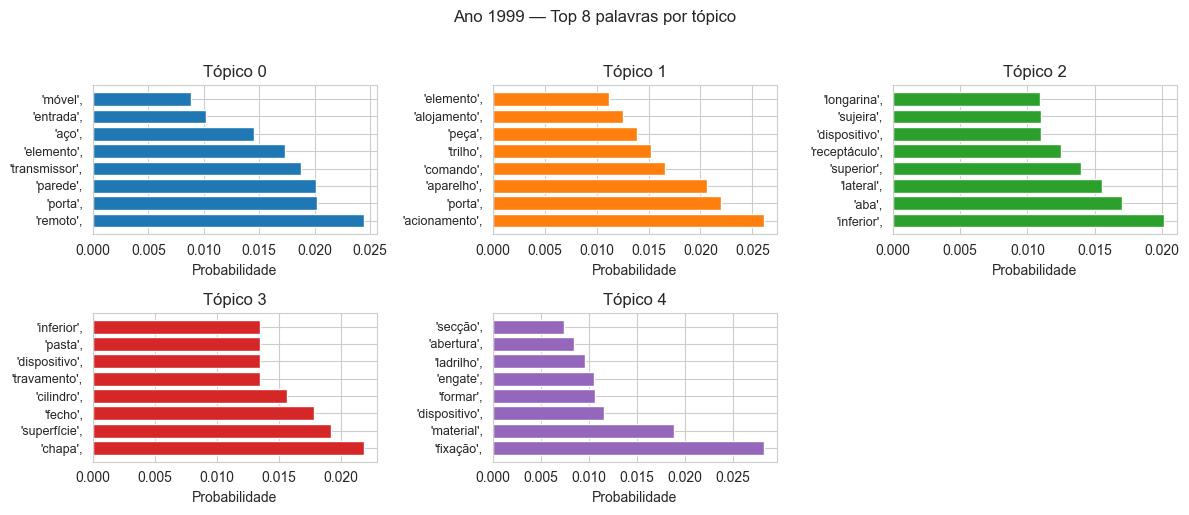


--- Tópicos para o Ano: 2000 ---
Tópico 0: 'painel', (1.37%), 'invenção', (1.04%), 'presente', (0.72%), 'construção', (0.70%), 'exibição', (0.68%), 'elemento', (0.66%), 'corpo', (0.62%), 'dispositivo', (0.61%)
Tópico 1: 'água', (1.13%), 'invenção', (1.06%), 'dispositivo', (0.88%), 'controle', (0.85%), 'outro', (0.57%), 'bloco', (0.57%), 'erosão', (0.57%), 'lateral', (0.50%)
Tópico 2: 'porta', (1.10%), 'outro', (0.96%), 'montagem', (0.94%), 'elemento', (0.90%), 'peça', (0.78%), 'construção', (0.75%), 'guia', (0.69%), 'lateral', (0.68%)
Tópico 3: 'corpo', (1.05%), 'extremidade', (0.88%), 'elemento', (0.80%), 'base', (0.68%), 'inferior', (0.60%), 'travamento', (0.60%), 'alto', (0.56%), 'abertura', (0.53%)
Tópico 4: 'superfície', (1.12%), 'elemento', (1.01%), 'liberação', (0.89%), 'água', (0.78%), 'parede', (0.74%), 'central', (0.73%), 'concreto', (0.70%), 'permitir', (0.62%)


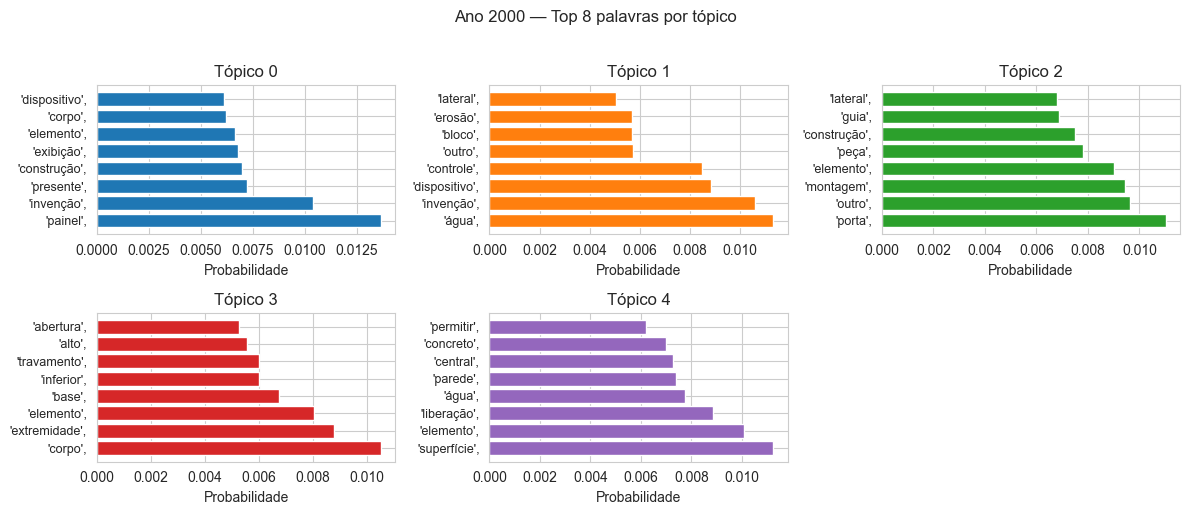


--- Tópicos para o Ano: 2001 ---
Tópico 0: 'caixa', (0.75%), 'água', (0.72%), 'porta', (0.59%), 'invenção', (0.54%), 'patente', (0.52%), 'dispositivo', (0.50%), 'peça', (0.50%), 'lateral', (0.46%)
Tópico 1: 'água', (0.93%), 'caixa', (0.63%), 'invenção', (0.61%), 'elemento', (0.61%), 'compreender', (0.52%), 'vertical', (0.52%), 'cilindro', (0.49%), 'comando', (0.49%)
Tópico 2: 'porta', (1.55%), 'água', (0.81%), 'suporte', (0.60%), 'corpo', (0.60%), 'fechadura', (0.60%), 'dispositivo', (0.58%), 'elemento', (0.56%), 'parafuso', (0.54%)
Tópico 3: 'estrutura', (0.96%), 'construção', (0.95%), 'montagem', (0.71%), 'batente', (0.69%), 'bloco', (0.61%), 'trar', (0.60%), 'civil', (0.59%), 'porta', (0.52%)
Tópico 4: 'material', (0.71%), 'invólucro', (0.68%), 'água', (0.60%), 'peça', (0.59%), 'produto', (0.56%), 'superfície', (0.53%), 'outro', (0.53%), 'dispositivo', (0.50%)


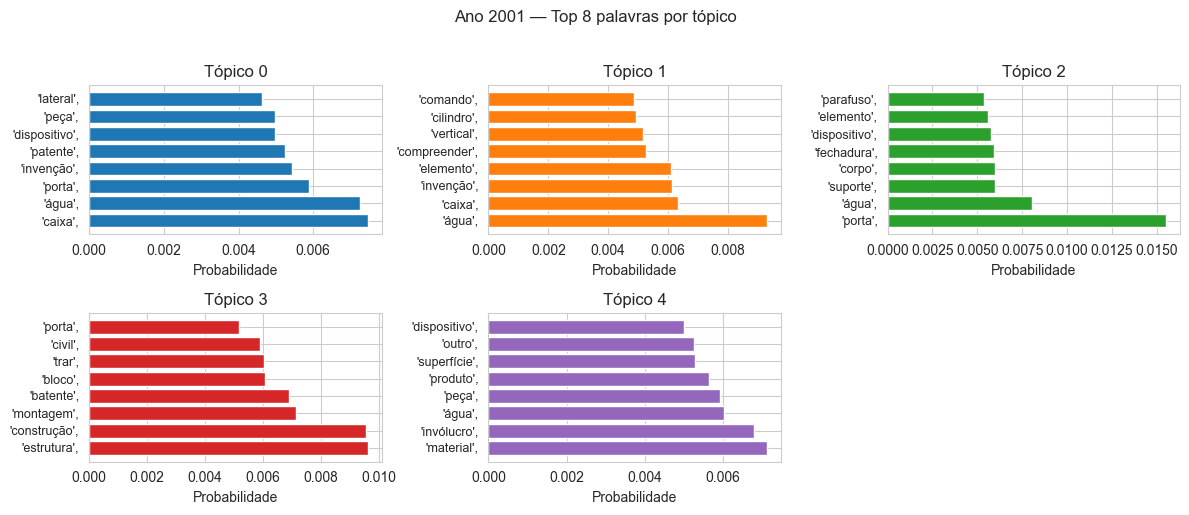


--- Tópicos para o Ano: 2002 ---
Tópico 0: 'corpo', (1.04%), 'material', (0.87%), 'dispositivo', (0.75%), 'elemento', (0.73%), 'condutor', (0.61%), 'transmissão', (0.59%), 'outro', (0.55%), 'concreto', (0.55%)
Tópico 1: 'caixa', (0.87%), 'elétrico', (0.85%), 'estrutura', (0.83%), 'outro', (0.77%), 'base', (0.66%), 'extremidade', (0.63%), 'filtro', (0.63%), 'lateral', (0.61%)
Tópico 2: 'porta', (1.71%), 'conjunto', (1.00%), 'compreender', (0.82%), 'peça', (0.67%), 'outro', (0.65%), 'dispositivo', (0.64%), 'acionamento', (0.59%), 'atuador', (0.59%)
Tópico 3: 'água', (1.08%), 'viga', (0.97%), 'painel', (0.91%), 'parede', (0.84%), 'construção', (0.82%), 'processo', (0.73%), 'outro', (0.59%), 'interno', (0.54%)
Tópico 4: 'conjunto', (1.02%), 'base', (0.87%), 'transportador', (0.87%), 'elemento', (0.81%), 'extremidade', (0.74%), 'produto', (0.72%), 'montagem', (0.67%), 'fixação', (0.67%)


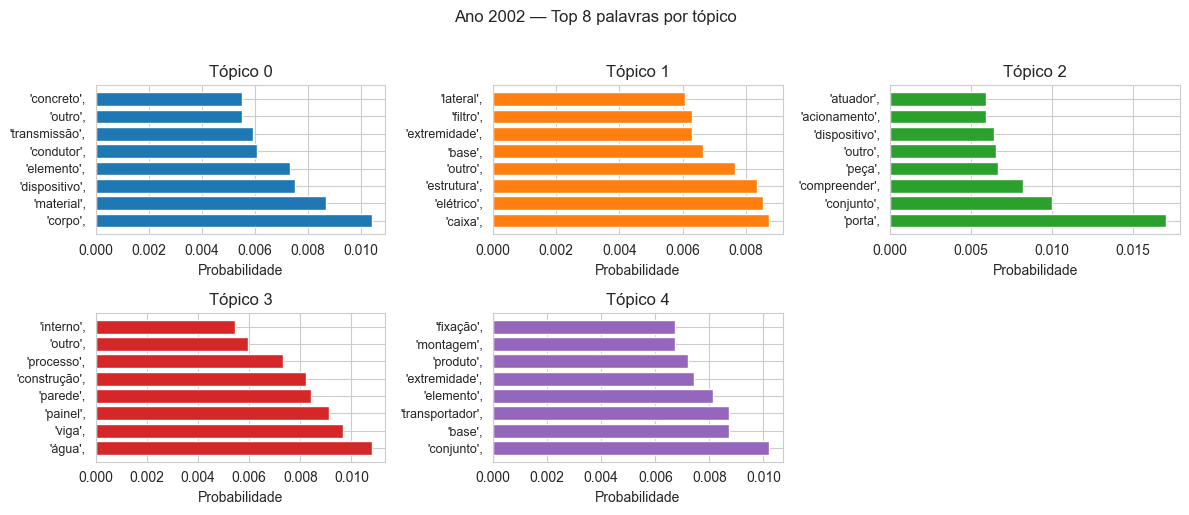


--- Tópicos para o Ano: 2003 ---
Tópico 0: 'portão', (1.08%), 'interno', (0.91%), 'compreender', (0.73%), 'cabo', (0.69%), 'porta', (0.63%), 'parede', (0.57%), 'unidade', (0.57%), 'inferior', (0.56%)
Tópico 1: 'água', (1.42%), 'reservatório', (1.05%), 'vaso', (0.65%), 'barragem', (0.63%), 'dispositivo', (0.60%), 'invenção', (0.57%), 'suporte', (0.56%), 'invólucro', (0.50%)
Tópico 2: 'fig', (1.07%), 'estrutura', (1.04%), 'elemento', (1.04%), 'água', (0.77%), 'conjunto', (0.66%), 'interno', (0.61%), 'equipamento', (0.56%), 'óleo', (0.52%)
Tópico 3: 'tubulação', (1.25%), 'dispositivo', (1.10%), 'válvula', (0.99%), 'fixação', (0.75%), 'parede', (0.75%), 'corpo', (0.73%), 'descarga', (0.72%), 'tijolo', (0.71%)
Tópico 4: 'elemento', (1.07%), 'estrutura', (1.01%), 'extremidade', (0.95%), 'parede', (0.91%), 'construção', (0.84%), 'fixação', (0.81%), 'viga', (0.80%), 'material', (0.76%)


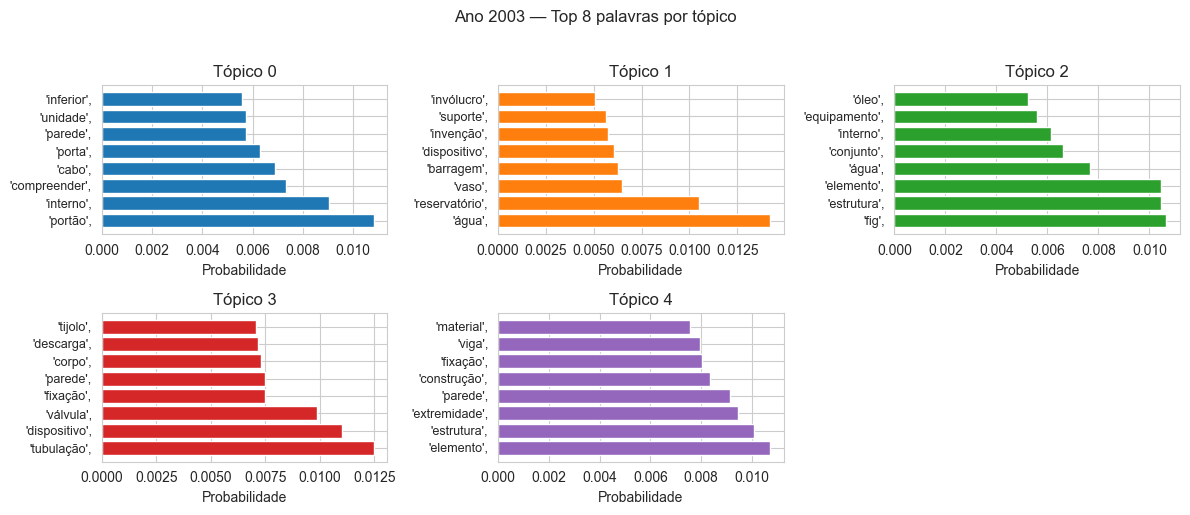


--- Tópicos para o Ano: 2004 ---
Tópico 0: 'porta', (1.50%), 'fechadura', (1.08%), 'dispositivo', (1.02%), 'bloco', (0.90%), 'elemento', (0.87%), 'compreender', (0.81%), 'estrutura', (0.72%), 'interno', (0.70%)
Tópico 1: 'porta', (1.60%), 'tijolo', (0.94%), 'parede', (0.92%), 'construção', (0.70%), 'possuir', (0.67%), 'material', (0.67%), 'face', (0.63%), 'inferior', (0.62%)
Tópico 2: 'peça', (1.20%), 'porta', (0.85%), 'elemento', (0.71%), 'porção', (0.68%), 'outro', (0.65%), 'estrutura', (0.64%), 'eixo', (0.63%), 'energia', (0.61%)
Tópico 3: 'elemento', (1.58%), 'perfil', (1.24%), 'conjunto', (0.97%), 'construção', (0.77%), 'vedação', (0.73%), 'dispositivo', (0.70%), 'mecanismo', (0.63%), 'formar', (0.58%)
Tópico 4: 'material', (1.10%), 'cilindro', (0.77%), 'aplicar', (0.72%), 'outro', (0.72%), 'invenção', (0.67%), 'anel', (0.64%), 'dispositivo', (0.62%), 'proteção', (0.55%)


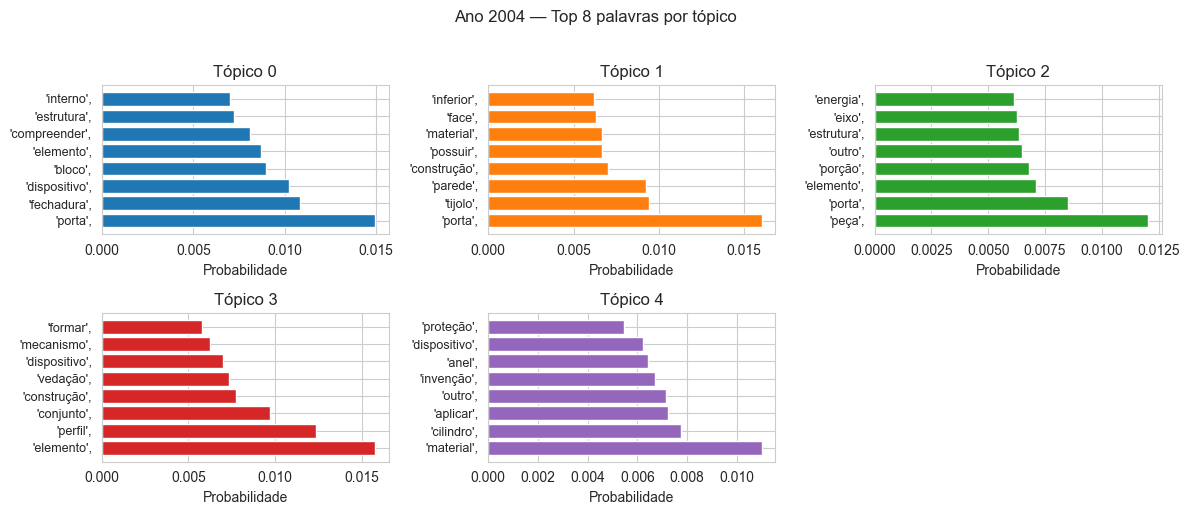


--- Tópicos para o Ano: 2005 ---
Tópico 0: 'sanitário', (1.11%), 'abertura', (0.97%), 'porta', (0.95%), 'giro', (0.74%), 'fechadura', (0.73%), 'suporte', (0.67%), 'membro', (0.63%), 'descarga', (0.61%)
Tópico 1: 'lateral', (1.00%), 'elemento', (0.91%), 'chave', (0.86%), 'fixação', (0.84%), 'parede', (0.77%), 'dispositivo', (0.75%), 'água', (0.75%), 'extremidade', (0.70%)
Tópico 2: 'concreto', (0.86%), 'solo', (0.85%), 'viga', (0.73%), 'invenção', (0.63%), 'haste', (0.63%), 'presente', (0.60%), 'revestimento', (0.59%), 'fixação', (0.55%)
Tópico 3: 'porta', (0.99%), 'material', (0.77%), 'elemento', (0.77%), 'outro', (0.70%), 'tubo', (0.66%), 'base', (0.65%), 'vedação', (0.59%), 'peça', (0.57%)
Tópico 4: 'dispositivo', (0.97%), 'chave', (0.83%), 'mecanismo', (0.61%), 'equipamento', (0.59%), 'travamento', (0.58%), 'base', (0.57%), 'corpo', (0.56%), 'modelo', (0.55%)


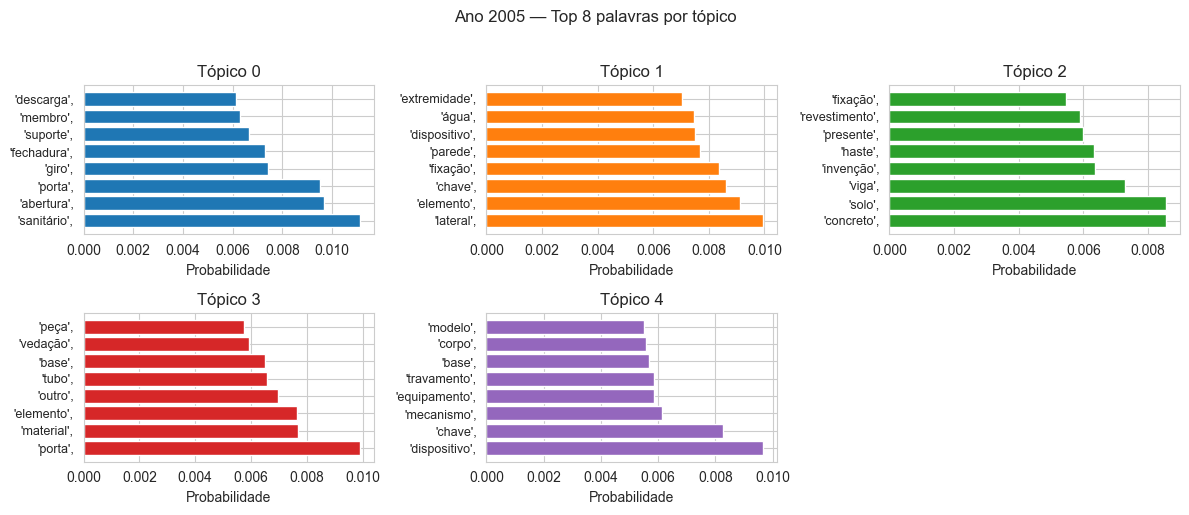


--- Tópicos para o Ano: 2006 ---
Tópico 0: 'elemento', (1.84%), 'estrutura', (1.05%), 'extremidade', (1.02%), 'estrutural', (0.82%), 'perfil', (0.81%), 'dente', (0.81%), 'lateral', (0.78%), 'corpo', (0.76%)
Tópico 1: 'parede', (1.76%), 'concreto', (1.09%), 'vaso', (0.89%), 'sanitário', (0.83%), 'pressão', (0.81%), 'estrutura', (0.72%), 'dispositivo', (0.68%), 'formar', (0.66%)
Tópico 2: 'caixa', (0.75%), 'chave', (0.72%), 'introduzer', (0.71%), 'invenção', (0.71%), 'disposição', (0.56%), 'descarga', (0.55%), 'corpo', (0.54%), 'patente', (0.51%)
Tópico 3: 'compreender', (0.86%), 'dispositivo', (0.75%), 'outro', (0.68%), 'construtivo', (0.67%), 'parede', (0.63%), 'base', (0.60%), 'encaixe', (0.59%), 'painel', (0.58%)
Tópico 4: 'caixa', (0.88%), 'instalação', (0.87%), 'corpo', (0.66%), 'tubo', (0.59%), 'dispositivo', (0.54%), 'água', (0.52%), 'permitir', (0.50%), 'outro', (0.46%)


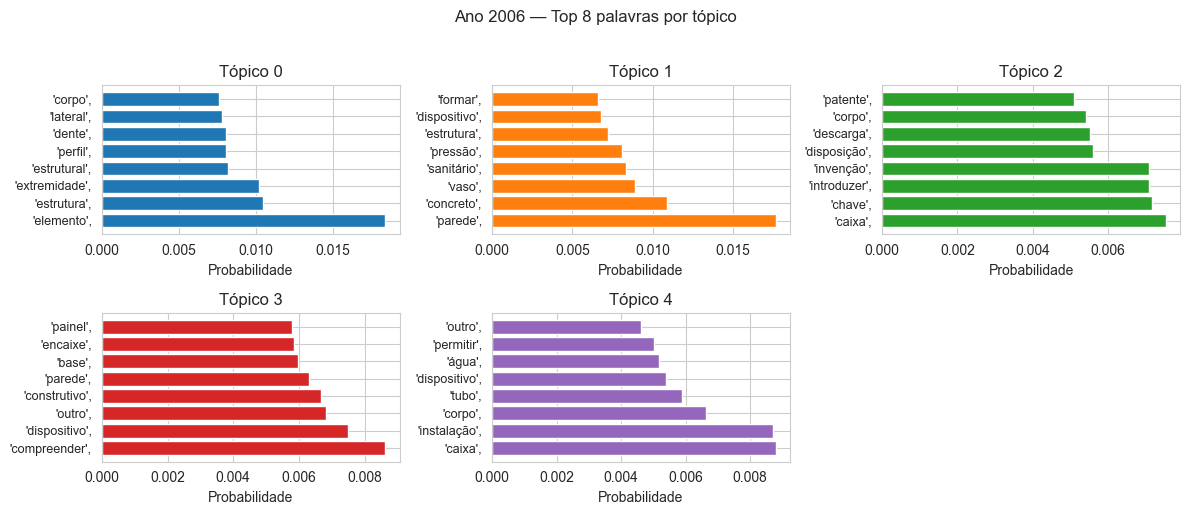


--- Tópicos para o Ano: 2007 ---
Tópico 0: 'água', (3.83%), 'piscina', (0.94%), 'dispositivo', (0.74%), 'válvula', (0.68%), 'inferior', (0.66%), 'saída', (0.60%), 'compreender', (0.58%), 'metálico', (0.57%)
Tópico 1: 'porta', (2.07%), 'outro', (1.18%), 'pino', (1.10%), 'trar', (1.05%), 'peça', (0.91%), 'segurança', (0.78%), 'haste', (0.64%), 'conjunto', (0.61%)
Tópico 2: 'fixação', (0.94%), 'base', (0.84%), 'fechadura', (0.75%), 'encaixe', (0.74%), 'dispositivo', (0.68%), 'trilho', (0.63%), 'anel', (0.62%), 'paralelo', (0.62%)
Tópico 3: 'setor', (0.89%), 'painel', (0.82%), 'trilho', (0.82%), 'camada', (0.75%), 'material', (0.69%), 'viga', (0.66%), 'térmico', (0.62%), 'acústico', (0.62%)
Tópico 4: 'piso', (1.18%), 'encaixe', (0.96%), 'dispositivo', (0.90%), 'fixação', (0.85%), 'estrutura', (0.81%), 'abertura', (0.81%), 'formar', (0.80%), 'bloco', (0.79%)


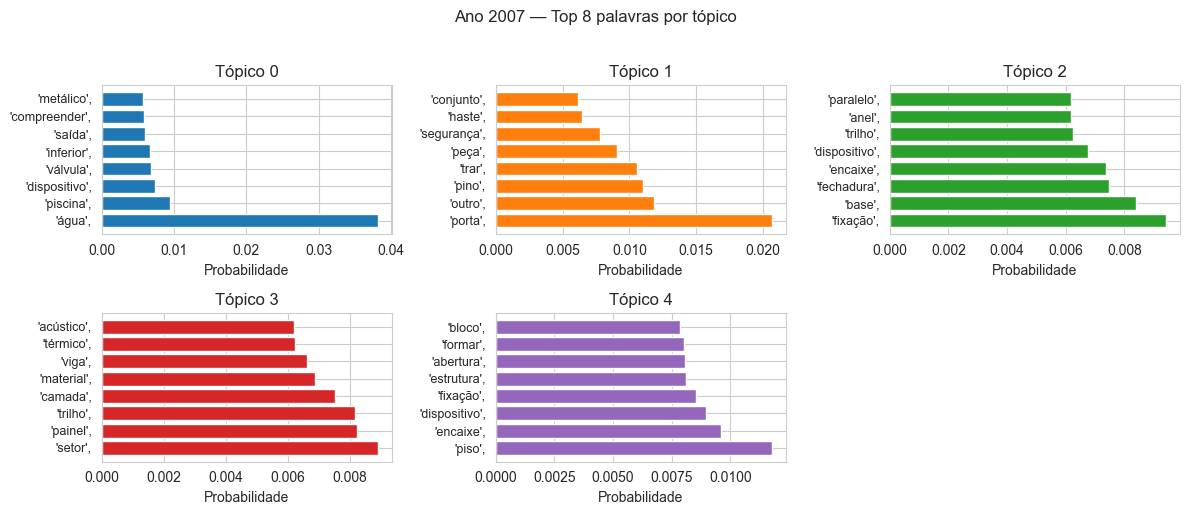


--- Tópicos para o Ano: 2008 ---
Tópico 0: 'painel', (1.23%), 'estrutura', (1.07%), 'perfis', (1.00%), 'água', (0.98%), 'porta', (0.92%), 'estrutural', (0.89%), 'placa', (0.68%), 'formar', (0.67%)
Tópico 1: 'peça', (1.19%), 'outro', (0.87%), 'modelo', (0.74%), 'acabamento', (0.72%), 'encaixe', (0.63%), 'presente', (0.57%), 'prémoldar', (0.57%), 'tampa', (0.55%)
Tópico 2: 'água', (1.30%), 'painel', (1.12%), 'trar', (0.77%), 'construtivo', (0.72%), 'cortina', (0.67%), 'modo', (0.63%), 'utilizar', (0.63%), 'inferior', (0.63%)
Tópico 3: 'plataforma', (0.91%), 'porta', (0.81%), 'tira', (0.67%), 'presente', (0.61%), 'folha', (0.61%), 'invenção', (0.61%), 'compreender', (0.60%), 'travamento', (0.55%)
Tópico 4: 'elemento', (1.66%), 'parede', (0.99%), 'estrutura', (0.89%), 'fixação', (0.83%), 'compreender', (0.74%), 'travamento', (0.67%), 'armação', (0.66%), 'pressão', (0.62%)


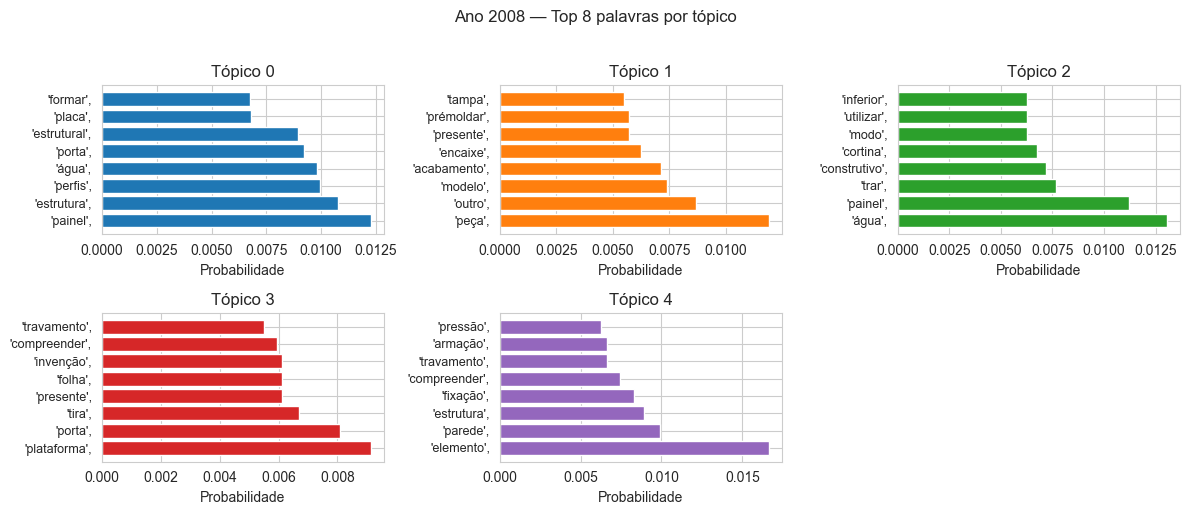


--- Tópicos para o Ano: 2009 ---
Tópico 0: 'porta', (1.43%), 'material', (1.10%), 'janela', (1.00%), 'elemento', (0.74%), 'dispositivo', (0.74%), 'estrutura', (0.69%), 'conjunto', (0.63%), 'compreender', (0.63%)
Tópico 1: 'suporte', (1.04%), 'elemento', (1.03%), 'tijolo', (0.81%), 'parede', (0.78%), 'fixação', (0.74%), 'conjunto', (0.74%), 'base', (0.67%), 'introduzer', (0.60%)
Tópico 2: 'dispositivo', (1.10%), 'outro', (0.88%), 'piso', (0.71%), 'água', (0.58%), 'presente', (0.52%), 'concreto', (0.49%), 'parede', (0.49%), 'corrediça', (0.49%)
Tópico 3: 'manta', (1.14%), 'dispositivo', (0.90%), 'autoadesivo', (0.66%), 'uso', (0.66%), 'tubulação', (0.60%), 'água', (0.59%), 'parede', (0.59%), 'piso', (0.58%)
Tópico 4: 'abertura', (1.74%), 'diâmetro', (1.08%), 'pequeno', (0.74%), 'água', (0.69%), 'haste', (0.68%), 'método', (0.62%), 'fundo', (0.61%), 'base', (0.61%)


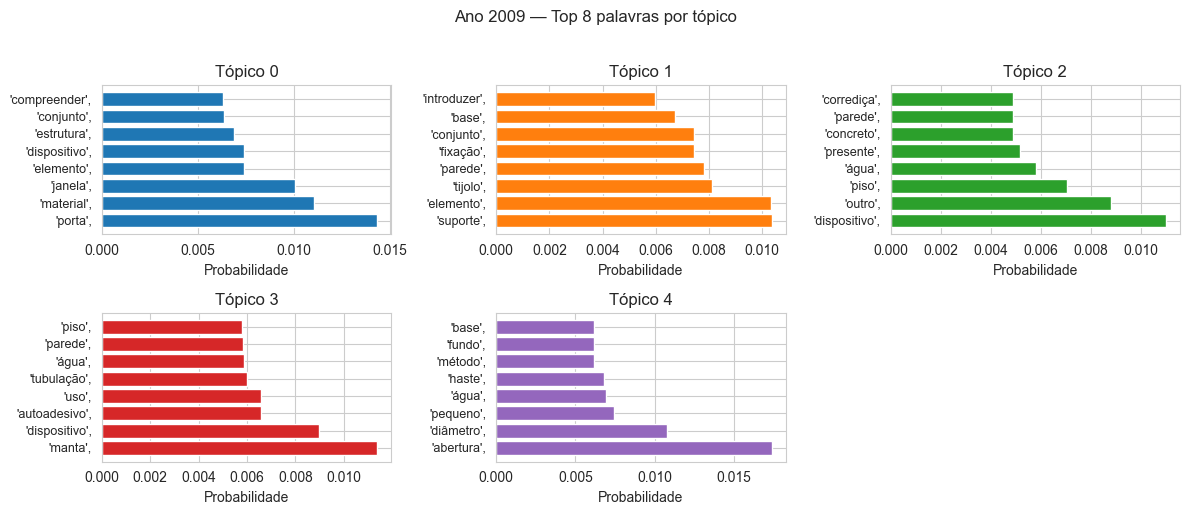


--- Tópicos para o Ano: 2010 ---
Tópico 0: 'fechamento', (0.91%), 'outro', (0.76%), 'possuir', (0.69%), 'dispositivo', (0.67%), 'material', (0.67%), 'furo', (0.63%), 'vertical', (0.62%), 'acabamento', (0.58%)
Tópico 1: 'placa', (1.33%), 'disposição', (0.73%), 'introduzer', (0.73%), 'barra', (0.67%), 'formato', (0.60%), 'jato', (0.54%), 'patente', (0.54%), 'água', (0.54%)
Tópico 2: 'item', (1.34%), 'porta', (0.93%), 'parede', (0.88%), 'cadeado', (0.83%), 'corpo', (0.74%), 'peça', (0.70%), 'água', (0.61%), 'formar', (0.56%)
Tópico 3: 'água', (2.34%), 'painel', (1.06%), 'tubo', (0.80%), 'cobertura', (0.74%), 'permitir', (0.74%), 'reservatório', (0.67%), 'alto', (0.66%), 'controle', (0.61%)
Tópico 4: 'porta', (1.61%), 'eixo', (0.86%), 'inferior', (0.81%), 'metálico', (0.72%), 'compreender', (0.67%), 'superior', (0.66%), 'tubo', (0.63%), 'mecanismo', (0.62%)


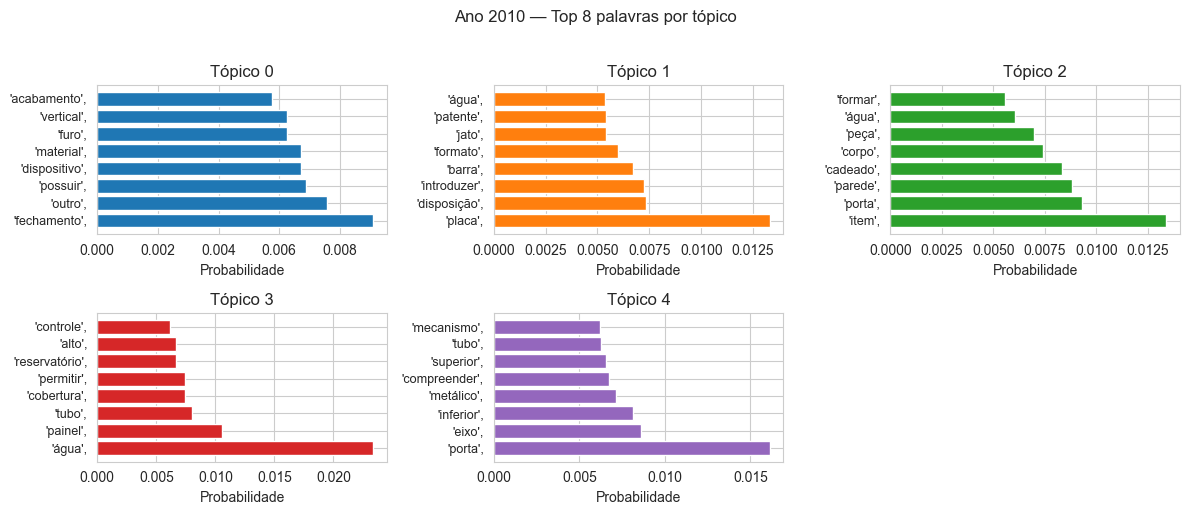


--- Tópicos para o Ano: 2011 ---
Tópico 0: 'porta', (2.49%), 'dispositivo', (1.83%), 'água', (1.64%), 'descarga', (0.96%), 'travamento', (0.92%), 'fechadura', (0.77%), 'presente', (0.70%), 'conjunto', (0.67%)
Tópico 1: 'elemento', (1.63%), 'água', (1.38%), 'parede', (1.08%), 'apresentar', (0.69%), 'inferior', (0.64%), 'lateral', (0.63%), 'revestimento', (0.58%), 'compreender', (0.55%)
Tópico 2: 'metálico', (1.07%), 'elemento', (0.93%), 'parede', (0.87%), 'água', (0.83%), 'construtivo', (0.82%), 'fixação', (0.73%), 'laje', (0.73%), 'plástico', (0.69%)
Tópico 3: 'painel', (1.41%), 'porta', (0.95%), 'viga', (0.82%), 'concreto', (0.82%), 'presente', (0.72%), 'outro', (0.72%), 'formar', (0.71%), 'escada', (0.69%)
Tópico 4: 'compreender', (1.06%), 'dispositivo', (1.01%), 'permitir', (0.92%), 'lateral', (0.76%), 'trilho', (0.71%), 'conjunto', (0.66%), 'base', (0.66%), 'formato', (0.61%)


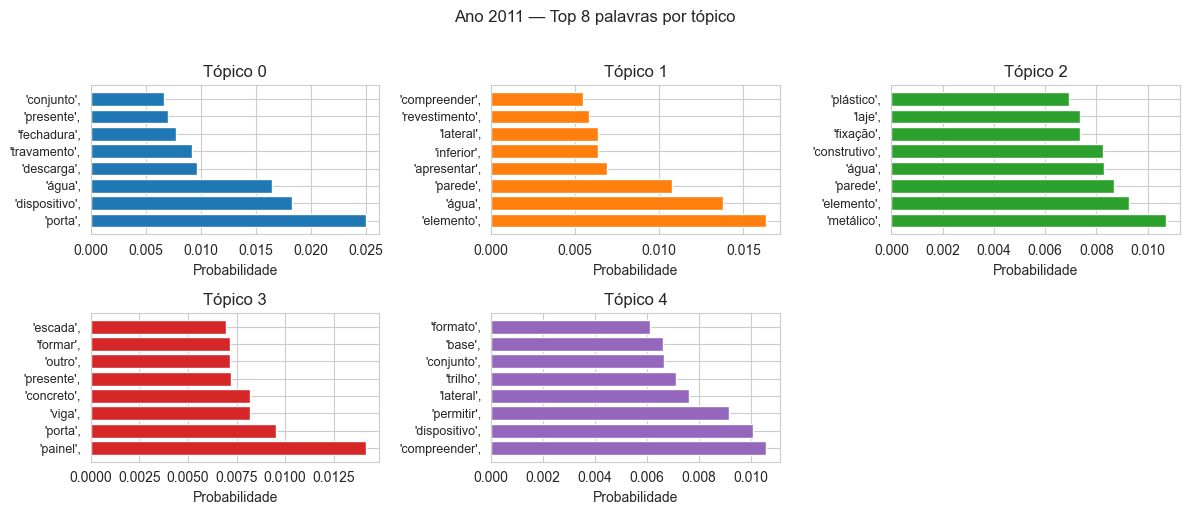


--- Tópicos para o Ano: 2012 ---
Tópico 0: 'suporte', (1.16%), 'porta', (1.02%), 'conjunto', (0.82%), 'extremidade', (0.82%), 'água', (0.69%), 'fixação', (0.64%), 'caixa', (0.63%), 'trilho', (0.62%)
Tópico 1: 'bloco', (1.86%), 'parede', (0.94%), 'construção', (0.86%), 'camada', (0.78%), 'conjunto', (0.71%), 'fixação', (0.63%), 'formar', (0.63%), 'pino', (0.63%)
Tópico 2: 'dentar', (0.94%), 'bloco', (0.94%), 'valeta', (0.82%), 'tratamento', (0.81%), 'dispositivo', (0.71%), 'correia', (0.71%), 'conjunto', (0.60%), 'muro', (0.60%)
Tópico 3: 'telha', (1.17%), 'introduzer', (0.98%), 'conjunto', (0.98%), 'água', (0.98%), 'suporte', (0.79%), 'assento', (0.79%), 'pedal', (0.79%), 'outro', (0.70%)
Tópico 4: 'dispositivo', (1.62%), 'material', (0.87%), 'travamento', (0.87%), 'viga', (0.77%), 'caixa', (0.76%), 'metálico', (0.68%), 'mesa', (0.68%), 'estrutura', (0.67%)


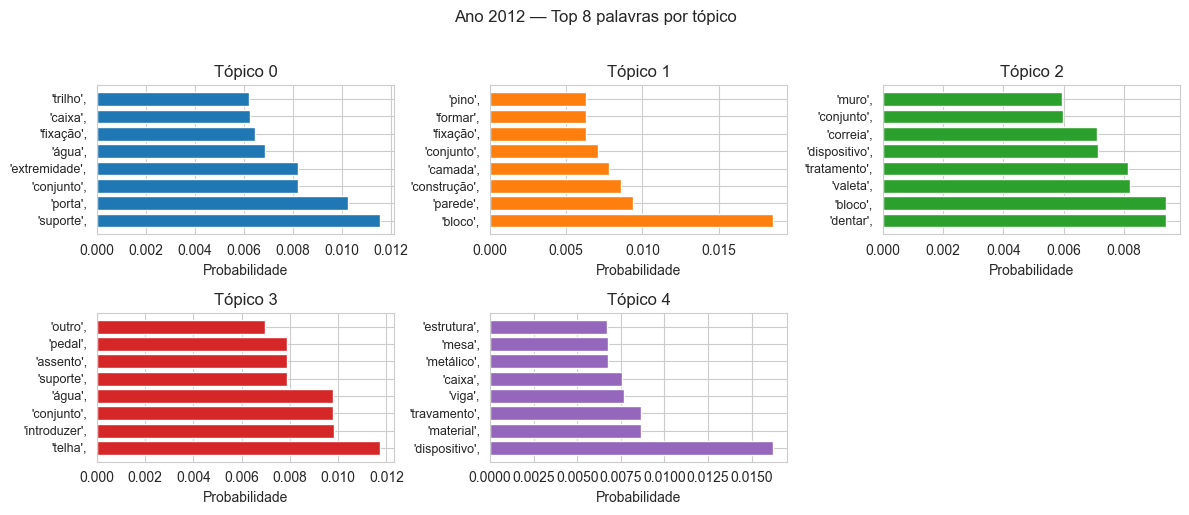


--- Tópicos para o Ano: 2013 ---
Tópico 0: 'fixação', (0.83%), 'compreender', (0.78%), 'concreto', (0.77%), 'elemento', (0.71%), 'estaca', (0.60%), 'peso', (0.54%), 'presente', (0.48%), 'invenção', (0.48%)
Tópico 1: 'água', (1.29%), 'aplicar', (0.74%), 'suporte', (0.73%), 'fixação', (0.65%), 'utilizar', (0.61%), 'presente', (0.51%), 'conjunto', (0.50%), 'superfície', (0.48%)
Tópico 2: 'painel', (1.18%), 'parede', (0.75%), 'peça', (0.75%), 'dispositivo', (0.71%), 'revestimento', (0.71%), 'conjunto', (0.64%), 'compreender', (0.56%), 'inferior', (0.53%)
Tópico 3: 'porta', (2.36%), 'água', (1.60%), 'janela', (0.94%), 'parede', (0.87%), 'invenção', (0.68%), 'processo', (0.61%), 'bloco', (0.60%), 'estrutura', (0.58%)
Tópico 4: 'parede', (1.04%), 'porta', (0.79%), 'construção', (0.79%), 'modular', (0.74%), 'elemento', (0.69%), 'componente', (0.63%), 'fixar', (0.60%), 'similar', (0.56%)


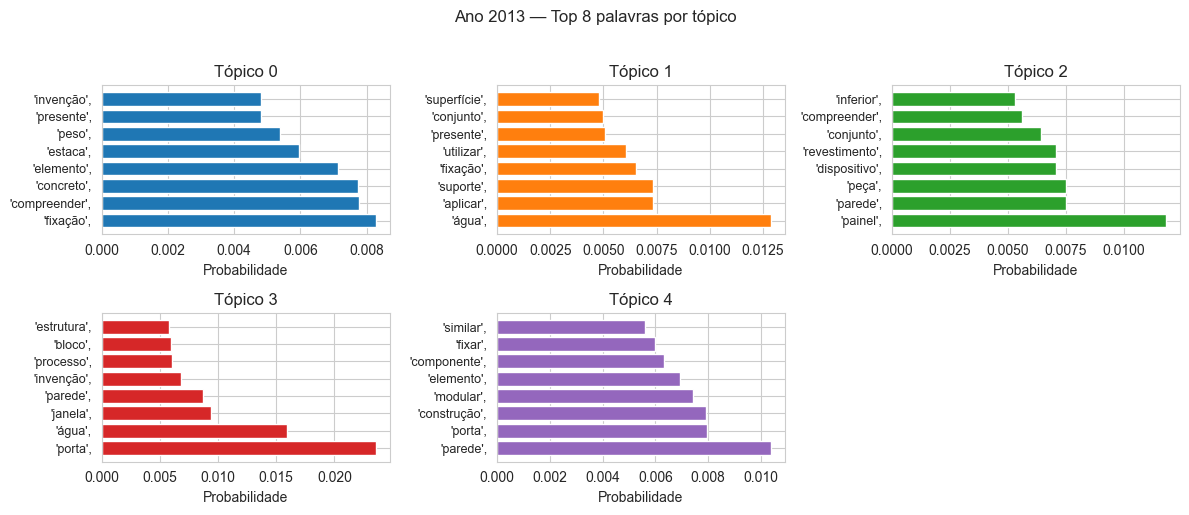


--- Tópicos para o Ano: 2014 ---
Tópico 0: 'fig', (3.64%), 'caixa', (1.06%), 'terminal', (0.95%), 'vidro', (0.72%), 'elemento', (0.72%), 'componente', (0.69%), 'plug', (0.62%), 'outro', (0.61%)
Tópico 1: 'caixa', (1.15%), 'eletrônico', (0.83%), 'água', (0.75%), 'parede', (0.75%), 'presente', (0.75%), 'cofre', (0.75%), 'estrutura', (0.74%), 'cédula', (0.58%)
Tópico 2: 'porta', (0.84%), 'segurança', (0.62%), 'introduzer', (0.62%), 'elemento', (0.57%), 'perfil', (0.51%), 'bloco', (0.51%), 'similar', (0.51%), 'disposição', (0.51%)
Tópico 3: 'peça', (1.66%), 'elemento', (0.87%), 'montagem', (0.86%), 'compreender', (0.79%), 'estrutura', (0.74%), 'corpo', (0.69%), 'parede', (0.69%), 'telha', (0.65%)
Tópico 4: 'sanitário', (0.83%), 'conjunto', (0.64%), 'travamento', (0.64%), 'dispositivo', (0.64%), 'porta', (0.64%), 'vaso', (0.64%), 'membro', (0.64%), 'correr', (0.57%)


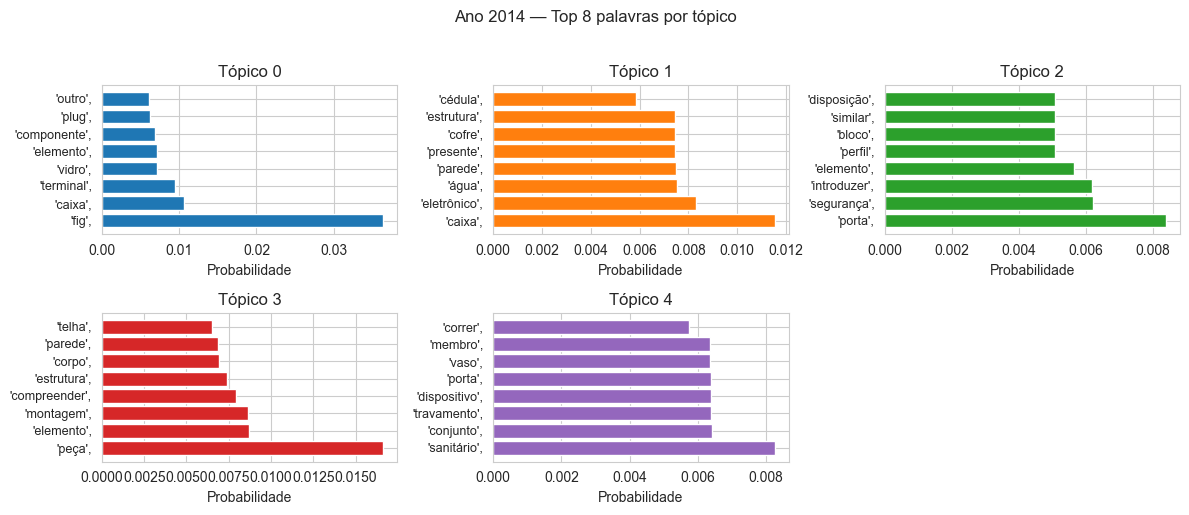


--- Tópicos para o Ano: 2015 ---
Tópico 0: 'escada', (0.97%), 'altura', (0.83%), 'conjunto', (0.75%), 'compreender', (0.68%), 'extremidade', (0.66%), 'presente', (0.59%), 'sela', (0.58%), 'degrau', (0.56%)
Tópico 1: 'reservatório', (0.77%), 'fresa', (0.72%), 'água', (0.72%), 'alojamento', (0.66%), 'introduzer', (0.63%), 'componente', (0.61%), 'processo', (0.60%), 'conjunto', (0.57%)
Tópico 2: 'caixa', (1.08%), 'chave', (0.81%), 'superfície', (0.76%), 'motor', (0.76%), 'controle', (0.71%), 'acionamento', (0.67%), 'lateral', (0.63%), 'base', (0.62%)
Tópico 3: 'água', (0.91%), 'outro', (0.88%), 'bloco', (0.82%), 'painel', (0.81%), 'invenção', (0.79%), 'caixa', (0.67%), 'parede', (0.66%), 'corpo', (0.58%)
Tópico 4: 'parede', (1.22%), 'elemento', (1.15%), 'porta', (1.07%), 'construção', (1.05%), 'construtivo', (1.01%), 'disposição', (0.82%), 'placa', (0.76%), 'metálico', (0.72%)


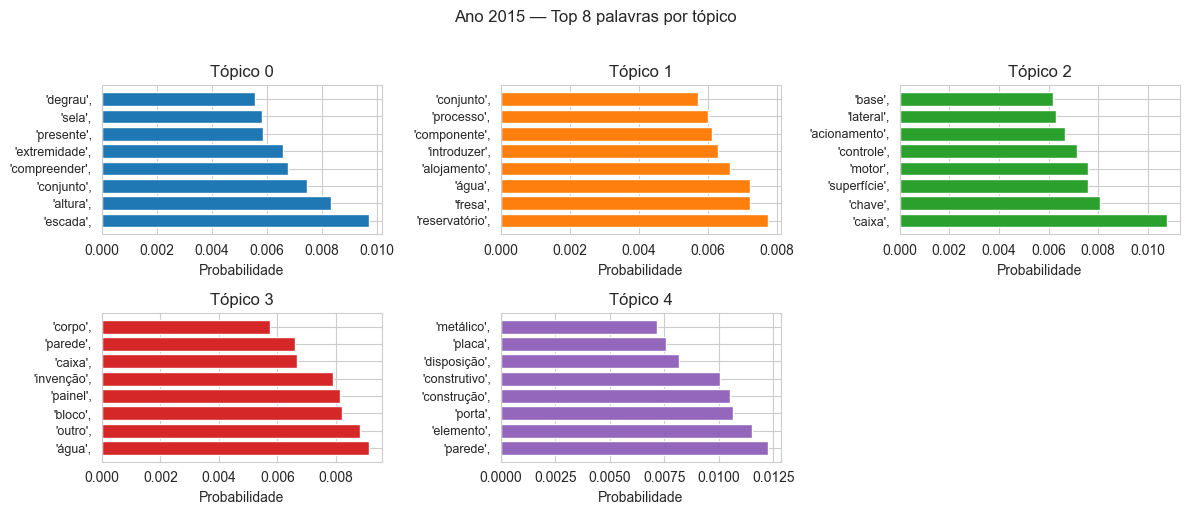


--- Tópicos para o Ano: 2016 ---
Tópico 0: 'concreto', (1.39%), 'invenção', (0.99%), 'módulo', (0.87%), 'presente', (0.71%), 'piso', (0.69%), 'água', (0.63%), 'compreender', (0.58%), 'construção', (0.57%)
Tópico 1: 'dispositivo', (1.08%), 'elemento', (0.69%), 'presente', (0.61%), 'conjunto', (0.58%), 'alto', (0.56%), 'compreender', (0.55%), 'parede', (0.55%), 'fixação', (0.54%)
Tópico 2: 'base', (0.79%), 'elemento', (0.76%), 'construtivo', (0.75%), 'tampa', (0.72%), 'hidráulico', (0.70%), 'compreender', (0.69%), 'acionador', (0.62%), 'água', (0.58%)
Tópico 3: 'construção', (0.82%), 'presente', (0.65%), 'compreender', (0.62%), 'aplicar', (0.60%), 'segurança', (0.59%), 'aparelho', (0.59%), 'porta', (0.58%), 'concreto', (0.57%)
Tópico 4: 'estrutura', (1.23%), 'compreender', (0.79%), 'dispositivo', (0.68%), 'porta', (0.66%), 'formar', (0.64%), 'travamento', (0.59%), 'material', (0.55%), 'mecanismo', (0.55%)


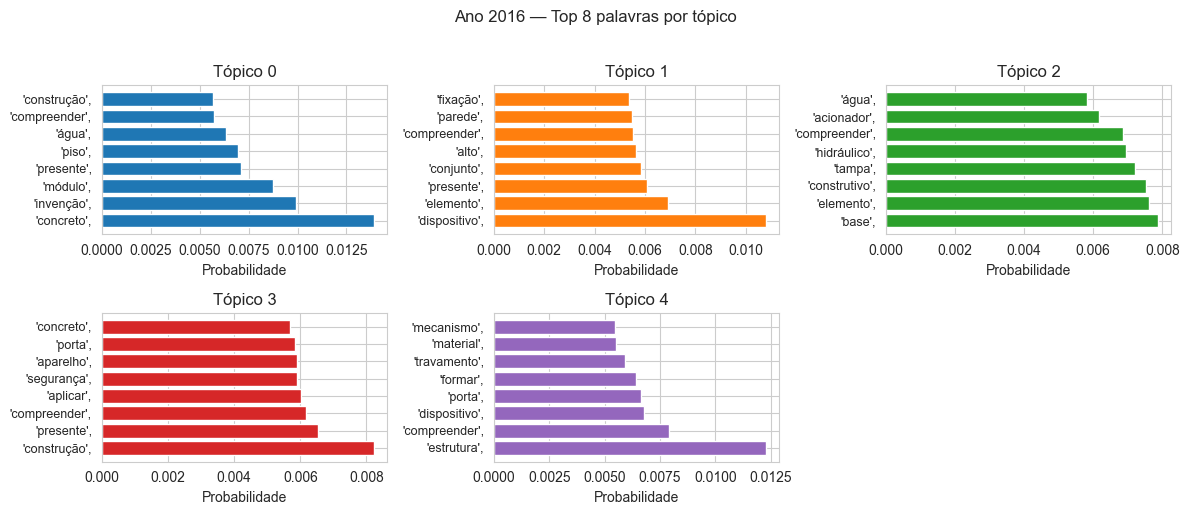


--- Tópicos para o Ano: 2017 ---
Tópico 0: 'elemento', (0.91%), 'travamento', (0.81%), 'invenção', (0.68%), 'dispositivo', (0.65%), 'mecanismo', (0.60%), 'compreender', (0.57%), 'porta', (0.56%), 'suporte', (0.55%)
Tópico 1: 'dispositivo', (0.91%), 'fixação', (0.82%), 'corpo', (0.70%), 'abertura', (0.61%), 'janela', (0.56%), 'elemento', (0.56%), 'compreender', (0.52%), 'extremidade', (0.49%)
Tópico 2: 'invenção', (1.12%), 'suporte', (0.82%), 'presente', (0.81%), 'compreender', (0.75%), 'porta', (0.66%), 'construção', (0.64%), 'energia', (0.59%), 'válvula', (0.59%)
Tópico 3: 'dispositivo', (1.32%), 'lateral', (0.97%), 'estrutura', (0.83%), 'compreender', (0.78%), 'porta', (0.70%), 'extremidade', (0.65%), 'incluir', (0.65%), 'membro', (0.64%)
Tópico 4: 'água', (1.71%), 'compreender', (1.02%), 'placa', (0.96%), 'porta', (0.83%), 'invenção', (0.78%), 'elemento', (0.71%), 'suporte', (0.55%), 'parede', (0.54%)


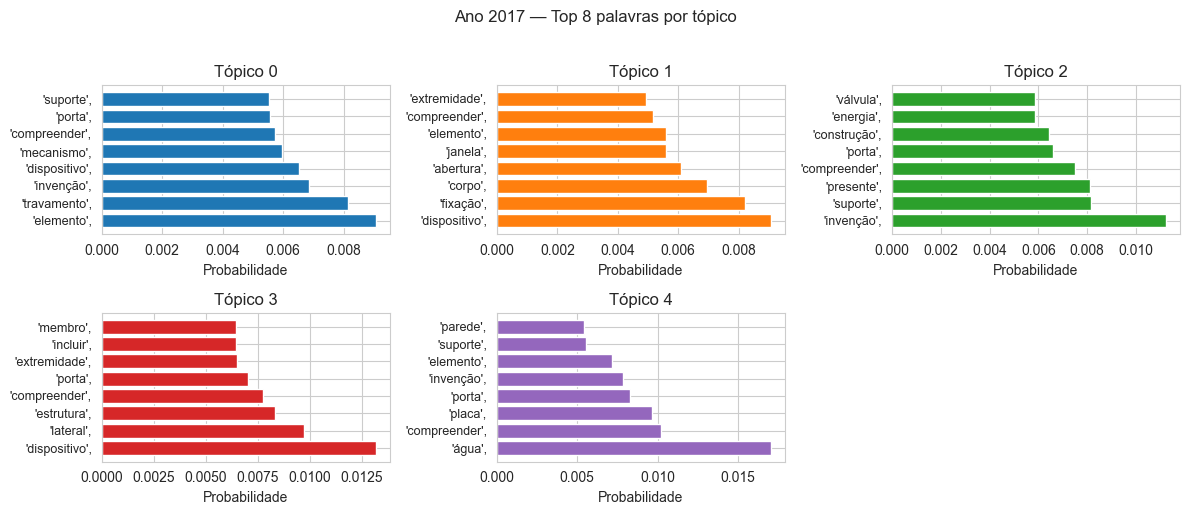


--- Tópicos para o Ano: 2018 ---
Tópico 0: 'compreender', (0.78%), 'porta', (0.76%), 'elemento', (0.62%), 'chave', (0.58%), 'dispositivo', (0.58%), 'conjunto', (0.57%), 'alto', (0.56%), 'plástico', (0.53%)
Tópico 1: 'compreender', (1.16%), 'invenção', (0.95%), 'elemento', (0.91%), 'presente', (0.89%), 'canal', (0.82%), 'água', (0.78%), 'gotejamento', (0.68%), 'base', (0.66%)
Tópico 2: 'dispositivo', (1.30%), 'água', (1.11%), 'compreender', (0.92%), 'caixa', (0.79%), 'estrutura', (0.67%), 'presente', (0.64%), 'borda', (0.50%), 'montagem', (0.48%)
Tópico 3: 'suporte', (1.11%), 'material', (0.83%), 'invenção', (0.72%), 'presente', (0.72%), 'porta', (0.66%), 'dobradiça', (0.64%), 'painel', (0.63%), 'eixo', (0.62%)
Tópico 4: 'base', (1.15%), 'conjunto', (1.14%), 'construtivo', (1.06%), 'disposição', (0.91%), 'montagem', (0.82%), 'introduzer', (0.82%), 'travamento', (0.78%), 'desgaste', (0.77%)


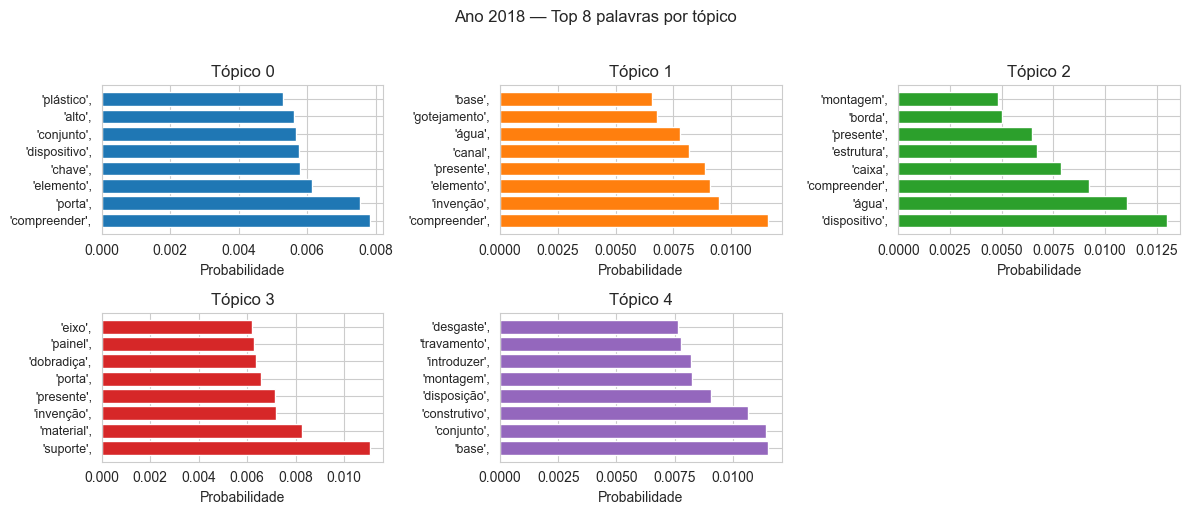


--- Tópicos para o Ano: 2019 ---
Tópico 0: 'vertical', (1.25%), 'porta', (1.25%), 'conjunto', (1.17%), 'suporte', (1.09%), 'estrutura', (0.74%), 'invenção', (0.71%), 'piso', (0.69%), 'construção', (0.68%)
Tópico 1: 'elemento', (1.65%), 'base', (0.96%), 'invenção', (0.76%), 'compreender', (0.74%), 'superfície', (0.70%), 'porção', (0.69%), 'presente', (0.69%), 'cobertura', (0.65%)
Tópico 2: 'água', (0.88%), 'modo', (0.80%), 'veículo', (0.72%), 'método', (0.69%), 'painel', (0.55%), 'formar', (0.55%), 'asfalto', (0.49%), 'incluir', (0.49%)
Tópico 3: 'painel', (0.88%), 'parede', (0.81%), 'compreender', (0.70%), 'invenção', (0.65%), 'presente', (0.64%), 'segmento', (0.57%), 'fixação', (0.54%), 'disposição', (0.53%)
Tópico 4: 'porta', (1.09%), 'base', (0.99%), 'parede', (0.90%), 'inferior', (0.88%), 'placa', (0.86%), 'compreender', (0.80%), 'lateral', (0.77%), 'superfície', (0.69%)


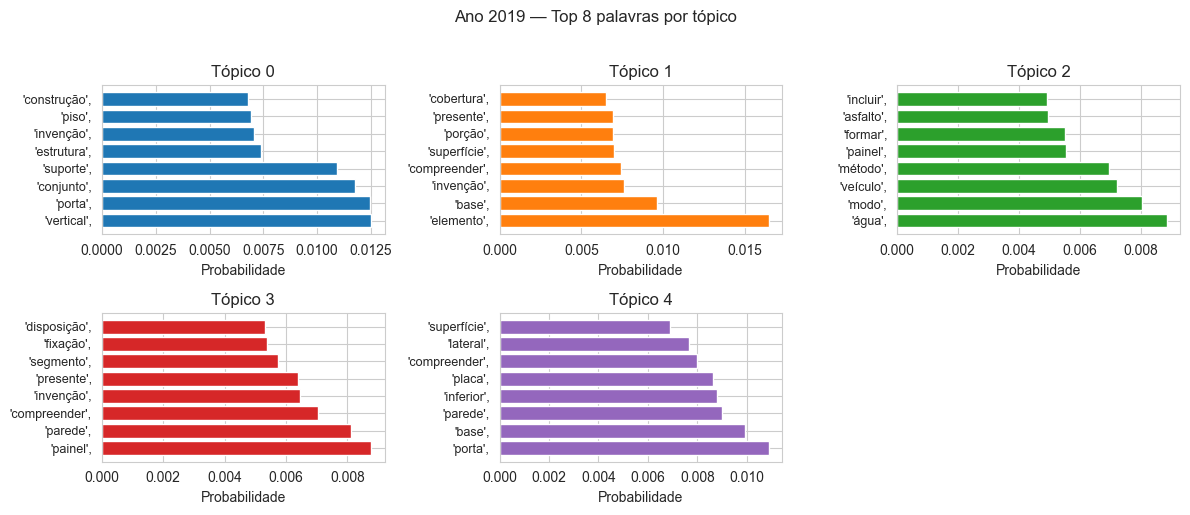


--- Tópicos para o Ano: 2020 ---
Tópico 0: 'dispositivo', (0.92%), 'porta', (0.92%), 'extremidade', (0.88%), 'compreender', (0.88%), 'suporte', (0.87%), 'elemento', (0.87%), 'invenção', (0.81%), 'aço', (0.70%)
Tópico 1: 'veículo', (1.12%), 'parede', (1.11%), 'compreender', (0.82%), 'material', (0.74%), 'estrutura', (0.71%), 'porta', (0.60%), 'aço', (0.56%), 'invenção', (0.56%)
Tópico 2: 'dispositivo', (1.12%), 'compreender', (0.91%), 'estrutura', (0.82%), 'torre', (0.70%), 'presente', (0.70%), 'conjunto', (0.66%), 'material', (0.65%), 'base', (0.64%)
Tópico 3: 'porta', (1.13%), 'travamento', (1.04%), 'elemento', (0.94%), 'painel', (0.89%), 'compreender', (0.81%), 'inferior', (0.73%), 'água', (0.68%), 'fixação', (0.67%)
Tópico 4: 'água', (1.63%), 'drenagem', (1.33%), 'porção', (1.27%), 'compreender', (0.92%), 'formar', (0.82%), 'parcial', (0.82%), 'energia', (0.69%), 'principal', (0.67%)


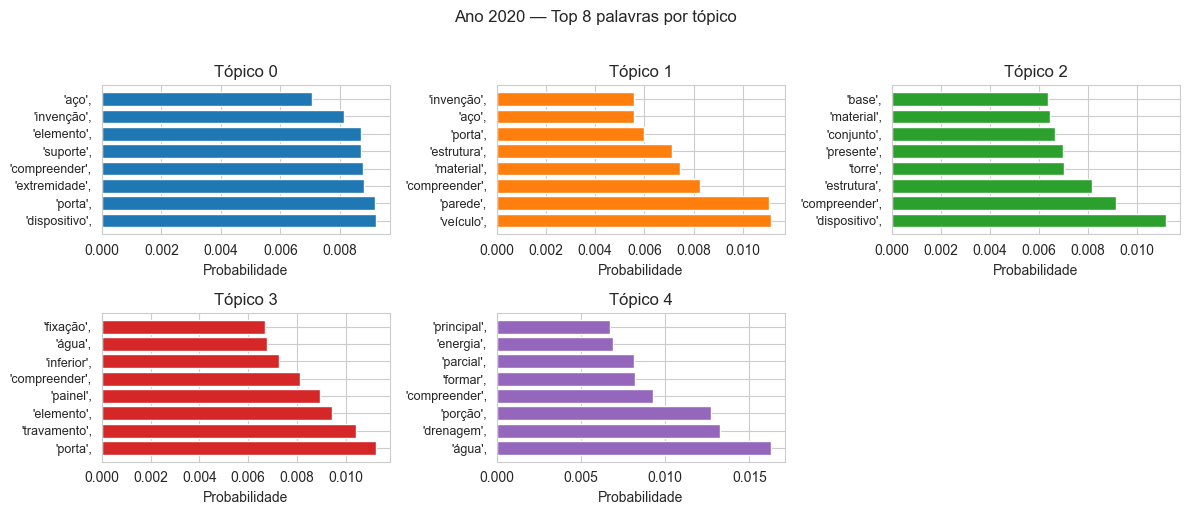


--- Tópicos para o Ano: 2021 ---
Tópico 0: 'torre', (0.94%), 'telecomunicação', (0.77%), 'água', (0.76%), 'painel', (0.70%), 'tubo', (0.68%), 'conjunto', (0.67%), 'compreender', (0.62%), 'invenção', (0.60%)
Tópico 1: 'porta', (1.39%), 'compreender', (0.93%), 'base', (0.86%), 'método', (0.84%), 'invenção', (0.81%), 'membro', (0.72%), 'presente', (0.71%), 'estrutura', (0.68%)
Tópico 2: 'elemento', (1.42%), 'compreender', (0.93%), 'invenção', (0.79%), 'dispositivo', (0.78%), 'construção', (0.75%), 'painel', (0.74%), 'referir', (0.69%), 'base', (0.68%)
Tópico 3: 'água', (0.98%), 'parede', (0.89%), 'ferramenta', (0.86%), 'incluir', (0.84%), 'solo', (0.80%), 'unidade', (0.74%), 'carga', (0.71%), 'abertura', (0.69%)
Tópico 4: 'desgaste', (1.10%), 'elemento', (1.07%), 'água', (1.06%), 'corpo', (0.99%), 'superfície', (0.90%), 'dispositivo', (0.79%), 'parede', (0.76%), 'membro', (0.75%)


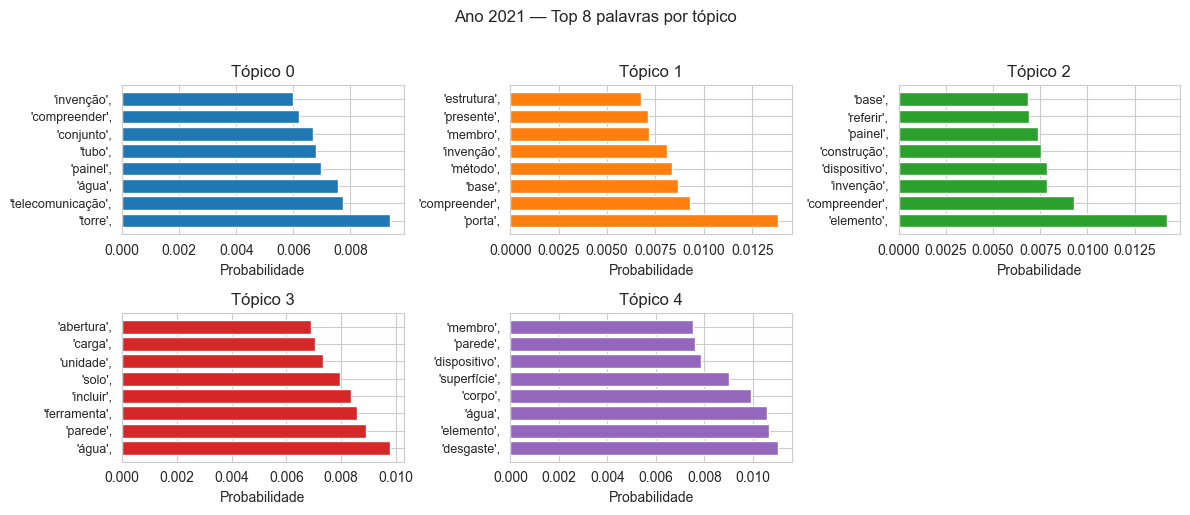


--- Tópicos para o Ano: 2022 ---
Tópico 0: 'painel', (1.72%), 'compreender', (1.01%), 'perfil', (0.89%), 'base', (0.70%), 'extremidade', (0.64%), 'borda', (0.64%), 'invenção', (0.58%), 'dispositivo', (0.54%)
Tópico 1: 'compreender', (1.09%), 'corpo', (0.84%), 'presente', (0.83%), 'aço', (0.79%), 'invenção', (0.79%), 'metálico', (0.66%), 'água', (0.58%), 'base', (0.58%)
Tópico 2: 'superfície', (1.58%), 'elemento', (1.34%), 'porta', (1.26%), 'incluir', (1.15%), 'método', (1.06%), 'porção', (0.85%), 'compreender', (0.73%), 'suporte', (0.72%)
Tópico 3: 'estrutura', (1.17%), 'invenção', (0.85%), 'presente', (0.83%), 'extremidade', (0.77%), 'peça', (0.77%), 'desgaste', (0.73%), 'bloco', (0.73%), 'superfície', (0.72%)
Tópico 4: 'água', (0.96%), 'dispositivo', (0.93%), 'estrutura', (0.84%), 'compreender', (0.71%), 'elemento', (0.71%), 'método', (0.69%), 'construção', (0.68%), 'cabo', (0.65%)


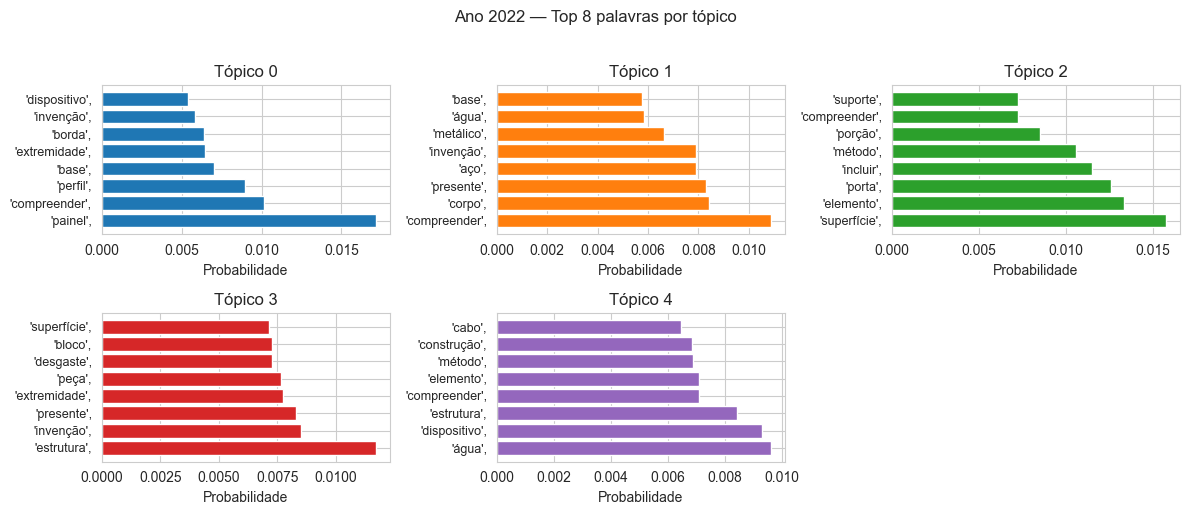


--- Tópicos para o Ano: 2023 ---
Tópico 0: 'elemento', (1.07%), 'compreender', (1.04%), 'presente', (1.01%), 'construtivo', (0.99%), 'porção', (0.91%), 'modelo', (0.86%), 'extremidade', (0.80%), 'inferior', (0.80%)
Tópico 1: 'unidade', (1.64%), 'válvula', (1.28%), 'montagem', (1.23%), 'limpeza', (1.13%), 'presente', (0.93%), 'invenção', (0.86%), 'alojamento', (0.67%), 'portão', (0.67%)
Tópico 2: 'porta', (1.53%), 'painel', (1.39%), 'compreender', (0.88%), 'extremidade', (0.83%), 'corpo', (0.83%), 'invenção', (0.80%), 'estrutura', (0.80%), 'fixação', (0.73%)
Tópico 3: 'método', (1.12%), 'estrutura', (1.01%), 'invenção', (0.90%), 'construção', (0.87%), 'presente', (0.73%), 'borda', (0.72%), 'sanitário', (0.68%), 'vaso', (0.68%)
Tópico 4: 'dispositivo', (1.10%), 'fechadura', (1.05%), 'conjunto', (0.89%), 'água', (0.84%), 'presente', (0.83%), 'energia', (0.69%), 'líquido', (0.65%), 'porta', (0.62%)


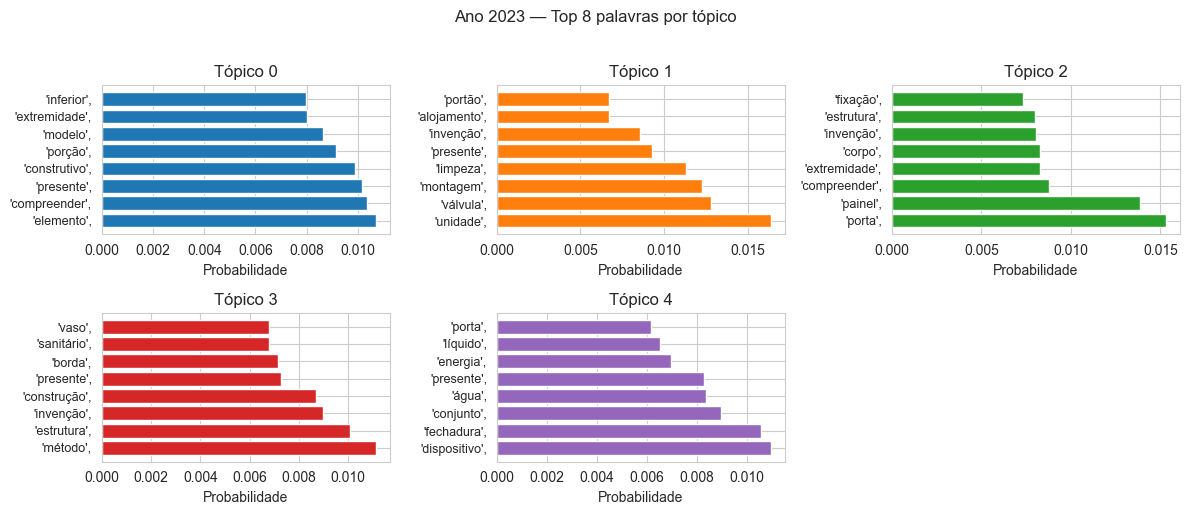


--- Tópicos para o Ano: 2024 ---
Tópico 0: 'elemento', (1.17%), 'presente', (0.92%), 'bloco', (0.79%), 'encaixe', (0.79%), 'rotor', (0.79%), 'lingueta', (0.79%), 'reflexão', (0.78%), 'refereser', (0.66%)
Tópico 1: 'trilho', (2.22%), 'trar', (1.54%), 'porta', (1.40%), 'fixação', (1.13%), 'longo', (1.13%), 'automatizar', (1.12%), 'material', (0.99%), 'soldagem', (0.99%)
Tópico 2: 'construção', (1.60%), 'aplicar', (1.29%), 'cruzeta', (1.13%), 'caixa', (1.13%), 'modular', (1.13%), 'máquina', (0.98%), 'chave', (0.97%), 'rádio', (0.97%)
Tópico 3: 'elemento', (2.49%), 'gancho', (2.49%), 'trar', (1.42%), 'compreender', (1.41%), 'mecânicohidráulico', (1.20%), 'extremidade', (1.20%), 'suspensão', (1.20%), 'membro', (1.09%)
Tópico 4: 'sanitário', (2.02%), 'água', (1.45%), 'recipiente', (1.17%), 'dado', (1.17%), 'base', (1.03%), 'saída', (1.03%), 'plataforma', (1.03%), 'humano', (1.03%)


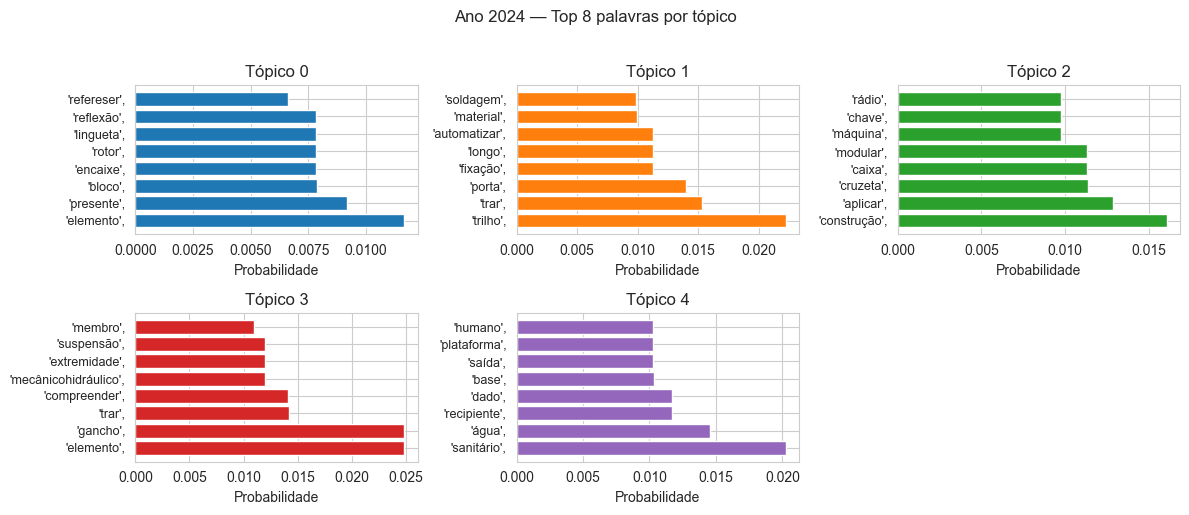

In [19]:
if TREINAR_MODELOS:
    print("\n" + "="*80)
    print("TREINAMENTO DE MODELOS LDA")
    print("="*80)
    
    train_and_save_lda_per_year(
        df=df_novo,
        num_topics=NUMERO_DE_TOPICOS,
        passes=10,
        output_dir=MODELS_DIR
    )
    
    # Exibe os tópicos dos modelos treinados
    print("\n--- Visualizando Tópicos dos Modelos ---")
    display_topics_from_models_with_probs(MODELS_DIR)
else:
    print("\n" + "="*80)
    print("TREINAMENTO PULADO (modelos já existem)")
    display_topics_from_models_with_probs(MODELS_DIR)
    print("="*80)

### Processamento das Patentes

In [23]:
if PROCESSAR_PATENTES:
    print("\n" + "="*80)
    print("PROCESSAMENTO DE PATENTES")
    print("="*80)
    
    analisar_e_salvar_por_ano_aprimorado(
        df=df_novo,
        modelos_dir=MODELS_DIR,
        num_topics=NUMERO_DE_TOPICOS,
        output_dir=RESULTS_DIR,
        ignorar_existentes=True
    )
else:
    print("\n" + "="*80)
    print("PROCESSAMENTO PULADO (resultados já existem)")
    print("="*80)


PROCESSAMENTO DE PATENTES
Iniciando análise para os anos: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Processando o ano: 1999
Modelo carregado
Pré-calculando distribuições de tópicos...
33 patentes para processar
Processando patentes...


33 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_1999.parquet

Processando o ano: 2000
Modelo carregado
Pré-calculando distribuições de tópicos...
175 patentes para processar
Processando patentes...


175 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2000.parquet

Processando o ano: 2001
Modelo carregado
Pré-calculando distribuições de tópicos...
163 patentes para processar
Processando patentes...


163 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2001.parquet

Processando o ano: 2002
Modelo carregado
Pré-calculando distribuições de tópicos...
135 patentes para processar
Processando patentes...


135 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2002.parquet

Processando o ano: 2003
Modelo carregado
Pré-calculando distribuições de tópicos...
115 patentes para processar
Processando patentes...


...

234 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2020.parquet

Processando o ano: 2021
Modelo carregado
Pré-calculando distribuições de tópicos...
249 patentes para processar
Processando patentes...


249 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2021.parquet

Processando o ano: 2022
Modelo carregado
Pré-calculando distribuições de tópicos...
253 patentes para processar
Processando patentes...


253 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2022.parquet

Processando o ano: 2023
Modelo carregado
Pré-calculando distribuições de tópicos...
157 patentes para processar
Processando patentes...


157 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2023.parquet

Processando o ano: 2024
Modelo carregado
Pré-calculando distribuições de tópicos...
40 patentes para processar
Processando patentes...


40 patentes processadas
✓ Salvo em Parquet: ./resultados_por_ano/5_topics/resultados_2024.parquet

PROCESSAMENTO CONCLUÍDO


### Dataframe com os Resultados (df_completo)

In [21]:
print("\n" + "="*80)
print("CONCATENANDO RESULTADOS")
print("="*80)

df_completo = concatenar_resultados_por_ano(
    diretorio_resultados=RESULTS_DIR,
    formato='auto'
)

if not df_completo.empty:
    # Converte colunas JSON para listas
    df_completo = converter_json_para_listas(df_completo)
    print("\nDados concatenados e convertidos com sucesso!")
    print(f"Total de patentes: {len(df_completo)}")
else:
    print("\nErro: Nenhum dado foi concatenado!")
    raise ValueError("Falha ao concatenar resultados")

topic_cols = [c for c in df_completo.columns if c.startswith('Topic_')]

if topic_cols:
    # chama a função definida em outro local passando topic_cols corretamente
    df_completo['dominant_topic'] = df_completo.apply(
        lambda row: _compute_dominant_topic(row, topic_cols), axis=1
    )
    print("\nColuna 'dominant_topic' adicionada. Distribuição:")
    print(df_completo['dominant_topic'].value_counts(dropna=False).head(10))
else:
    df_completo['dominant_topic'] = None
    print("\nNenhuma coluna 'Topic_' encontrada — 'dominant_topic' criada com None.")



CONCATENANDO RESULTADOS
⚠ Nenhum arquivo encontrado em './resultados_por_ano/5_topics/'

Erro: Nenhum dado foi concatenado!


ValueError: Falha ao concatenar resultados

### Analise de Patentes Jaccard

In [ ]:
if EXECUTAR_ANALISE_JACCARD:
    print("\n" + "="*80)
    print("ANÁLISE DE SIMILARIDADE (JACCARD)")
    print("="*80)
    
    df_analise_jaccard = analise_similaridade_jaccard(
        df_completo=df_completo,
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE,
        anos_a_frente=ANOS_A_FRENTE
    )
    print("Análise Jaccard concluída")
else:
    print("\n" + "="*80)
    print("CARREGANDO ANÁLISE JACCARD EXISTENTE")
    print("="*80)
    
    df_analise_jaccard = carregar_analise_jaccard(
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE,
        anos_a_frente=ANOS_A_FRENTE
    )
    if df_analise_jaccard is None:
        print("Erro ao carregar análise Jaccard!")
    else:
        print("Análise Jaccard carregada")

### Analise de Patentes Tanimoto

In [ ]:
if EXECUTAR_ANALISE_TANIMOTO:
        print("\n" + "="*80)
        print(f"ANÁLISE DE SIMILARIDADE (TANIMOTO)")
        print("="*80)
        
        df_analise_tanimoto = analise_similaridade_tanimoto_or_cosseno(
            df_completo=df_completo,
            numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
            percentual_similaridade=PERCENTUAL_SIMILARIDADE,
            metodo='tanimoto',
            anos_a_frente=ANOS_A_FRENTE
        )
        print(f"Análise tanimoto concluída")
else:
        print("\n" + "="*80)
        print(f"CARREGANDO ANÁLISE TANIMOTO EXISTENTE")
        print("="*80)
        
        df_analise_tanimoto = carregar_analise_tanimoto_ou_cosseno(
            numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
            percentual_similaridade=PERCENTUAL_SIMILARIDADE,
            metodo='tanimoto',
            anos_a_frente=ANOS_A_FRENTE
        )
        if df_analise_tanimoto is None:
            print(f"Erro ao carregar análise tanimoto!")
        else:
            print(f"Análise tanimoto carregada")

### Análise de Patentes Cossenos

In [ ]:
if EXECUTAR_ANALISE_COSSENO:
    print("\n" + "="*80)
    print(f"ANÁLISE DE SIMILARIDADE (COSSENOS)")
    print("="*80)
    
    df_analise_cosseno = analise_similaridade_tanimoto_or_cosseno(
        df_completo=df_completo,
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE,
        metodo='cossenos',
        anos_a_frente=ANOS_A_FRENTE
    )
    print(f"Análise cossenos concluída")
else:
    print("\n" + "="*80)
    print(f"CARREGANDO ANÁLISE COSSENO EXISTENTE")
    print("="*80)
    
    df_analise_cosseno = carregar_analise_tanimoto_ou_cosseno(
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE,
        metodo='cossenos',
        anos_a_frente=ANOS_A_FRENTE
    )
    if df_analise_cosseno is None:
        print(f"Erro ao carregar análise cossenos!")
    else:
        print(f"Análise cossenos carregada")

### Análise de Patentes por Tópico

In [ ]:
if EXECUTAR_ANALISE_TOPICOS:
    print("\n" + "="*80)
    print(f"ANÁLISE DE PATENTES VS TÓPICOS FUTUROS")
    print("="*80)
    
    df_analise_topicos = analise_emergencia_patente_topico(
        df_completo=df_completo,
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        metodo='cossenos',
        anos_a_frente=ANOS_A_FRENTE,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE
    )
else:
    print("\n" + "="*80)
    print(f"ANÁLISE DE PATENTES VS TÓPICOS FUTUROS PULADA")
    print("="*80)
    
    df_analise_topicos = carregar_analise_topicos(
        numero_palavras_por_topico=NUM_PALAVRAS_POR_TOPICO,
        metodo='cossenos',
        anos_a_frente=ANOS_A_FRENTE,
        percentual_similaridade=PERCENTUAL_SIMILARIDADE
    )
    if df_analise_topicos is None:
        print("Erro ao carregar análise de tópicos!")
    else:
        print("Análise de tópicos carregada com sucesso!")

### Calcular a intersecção entre tanimoto e cosseno

In [ ]:
if USE_INTERSECAO_FOR_ML:
    print("\n" + "="*80)
    print("CALCULANDO INTERSEÇÃO DAS ANÁLISES PARA ML")
    print("="*80)
    df_intersection = intersecao_emergentes_tanimoto_cosseno(df_analise_tanimoto, df_analise_cosseno)
    print("Numero de patentes na interseção:", int(df_intersection['emergente'].sum()))

### Análise junto da classificação do IPCR

In [ ]:
if USE_IPCR_FOR_ML:
    print("\n" + "="*80)
    print("ANÁLISE COM CLASSIFICAÇÃO IPCR")
    print("="*80)

    # Carrega dados IPCR
    filtered_ipcr = pd.read_csv(FILTERED_IPCR_PATH, compression='zip')
    print(f"Dataset IPCR carregado: {len(filtered_ipcr)} registros")

    if df_analise_jaccard is not None:
        # Análise com IPCR - Jaccard
        print("\n--- Analisando patentes emergentes (Jaccard) ---")
        df_resultado_jaccard, df_comparacoes_jaccard = analisar_com_ipcr(
            df_main=df_analise_jaccard,
            filtered_ipcr=filtered_ipcr
        )
        print("Análise IPCR (Jaccard) concluída")

    if df_analise_tanimoto is not None:
        # Análise com IPCR - Tanimoto
        print("\n--- Analisando patentes emergentes (Tanimoto) ---")
        df_resultado_tanimoto, df_comparacoes_tanimoto = analisar_com_ipcr(
            df_main=df_analise_tanimoto,
            filtered_ipcr=filtered_ipcr
        )
        print("Análise IPCR (Tanimoto) concluída")

    if df_analise_cosseno is not None:
        # Análise com IPCR - Cossenos
        print("\n--- Analisando patentes emergentes (Cossenos) ---")
        df_resultado_cosseno, df_comparacoes_cosseno = analisar_com_ipcr(
            df_main=df_analise_cosseno,
            filtered_ipcr=filtered_ipcr
        )
        print("Análise IPCR (Cossenos) concluída")

    if USE_INTERSECAO_FOR_ML and 'df_intersection' in locals():
        if df_intersection is not None:
            # Análise com IPCR - Interseção
            print("\n--- Analisando patentes emergentes (Interseção) ---")
            df_resultado_intersection, df_comparacoes_intersection = analisar_com_ipcr(
                df_main=df_intersection,
                filtered_ipcr=filtered_ipcr
            )
            print("Análise IPCR (Interseção) concluída")
else:
    print("\n" + "="*80)
    print("ANÁLISE COM CLASSIFICAÇÃO IPCR PULADA")
    print("="*80)

    print("Utilizando DataFrames originais para ML (sem IPCR)")

In [ ]:
# For each analysis dataframe, pick and display one emergent patent example (robust)

from IPython.display import display

candidate_names = ['df_analise_topicos', 'df_analise_tanimoto', 'df_analise_cosseno', 'df_intersection']
found_any = False


def _safe_parse_list(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return []
    if isinstance(val, list):
        return val
    f = globals().get('parse_list_safe')
    if callable(f):
        try:
            return f(val)
        except Exception:
            pass
    try:
        return ast.literal_eval(val) if isinstance(val, str) else [val]
    except Exception:
        return [val]


for name in candidate_names:
    df = globals().get(name, None)
    if df is None:
        print(f"- Skipping {name}: not in memory")
        continue
    if 'emergente' not in df.columns:
        print(f"- Skipping {name}: no 'emergente' column")
        continue

    try:
        mask = df['emergente'].fillna(False).astype(bool)
    except Exception:
        try:
            mask = df['emergente'].eq(True)
        except Exception:
            print(f"- Skipping {name}: cannot coerce 'emergente'")
            continue

    if not mask.any():
        print(f"- {name}: no emergent patents found")
        continue

    found_any = True
    candidates = df[mask].copy()

    # Prefer patent with largest 'count_similares' if column exists
    try:
        if 'count_similares' in candidates.columns:
            candidates['count_similares'] = pd.to_numeric(candidates['count_similares'], errors='coerce').fillna(0)
            sample_row = candidates.sort_values('count_similares', ascending=False).iloc[0]
        else:
            sample_row = candidates.sample(n=1, random_state=42).iloc[0]
    except Exception:
        sample_row = candidates.iloc[0]

    print('\n' + '='*60)
    print(f"Example from: {name}")
    print('Lens ID :', sample_row.get('lens_id'))
    print('Year    :', sample_row.get('year'))
    if 'dominant_topic' in df.columns:
        print('Dominant topic :', sample_row.get('dominant_topic'))
    if 'count_similares' in df.columns:
        print('Count similares :', sample_row.get('count_similares'))

    # patentes_similares
    if 'patentes_similares' in df.columns:
        simil = sample_row.get('patentes_similares')
        simil_list = _safe_parse_list(simil)
        print('Patentes similares (sample):', simil_list[:10])

    # show stored Topic_* columns
    topic_cols = [c for c in df.columns if c.startswith('Topic_')]
    if topic_cols:
        print('\nTop words per topic (from stored Topic_* columns):')
        for col in sorted(topic_cols):
            val = sample_row.get(col)
            if isinstance(val, str):
                try:
                    parsed = json.loads(val)
                except Exception:
                    parsed = _safe_parse_list(val)
            else:
                parsed = val
            if not parsed:
                continue
            display_list = parsed[:10]
            print(f"{col}: ", display_list)

    # Try to display original dataset row from df_novo if available
    if 'df_novo' in globals():
        try:
            lid = str(sample_row.get('lens_id')).strip()
            match = df_novo[df_novo['lens_id'].astype(str).str.strip() == lid]
            if not match.empty:
                print('\nOriginal dataset info (first match):')
                cols_to_show = [c for c in ['invention_title_text','abstract_text','title_abstract','tokens','date_published'] if c in match.columns]
                display(match[cols_to_show].iloc[0:1].T)
            else:
                print('\nNo matching row found in df_novo for this lens_id.')
        except Exception as e:
            print('\nCould not lookup original data in df_novo:', e)

    print('\n--- End Example ---')

if not found_any:
    print('\nNo emergent patents were found in any of the analysis dataframes in memory.')


### Preparação para o ML

In [ ]:
print("\n" + "="*80)
print("PREPARANDO DADOS PARA ML")
print("="*80)

# Merge com dados completos para ML
colunas_para_ml = ['lens_id', 'family_count', 'claims_count', 
                'ipcr_publication_years', 'new_ipcr']

if USE_IPCR_FOR_ML:
    colunas_existentes = [col for col in colunas_para_ml if col in filtered_ipcr.columns]
    
    df_train = pd.merge(
        df_novo,
        filtered_ipcr[colunas_existentes],
        on='lens_id',
        how='left'
    )
else:
    df_train = df_novo.copy()
print(f"Dataset de treino preparado: {df_train.shape}")

### Processar dados para o ML

In [ ]:
df_train['biblio_obj'] = df_train['biblio'].apply(parse_dict_safe)

df_train['cpc_obj'] = df_train['cpc_triples'].apply(parse_list_safe)

print("A extrair novas features...")

# Feature 1: num_cpc_codes
df_train['num_cpc_codes'] = df_train['cpc_obj'].apply(len)

# Feature 2: num_applicants
df_train['num_applicants'] = df_train['biblio_obj'].apply(
    lambda x: len(x.get('parties', {}).get('applicants', []))
)

# Feature 3: num_priority_claims
df_train['num_priority_claims'] = df_train['biblio_obj'].apply(
    lambda x: len(x.get('priority_claims', {}).get('claims', []))
)

# Feature 4: has_foreign_priority (Booleano: True/False)
def check_foreign_priority(biblio_dict):
    claims_list = biblio_dict.get('priority_claims', {}).get('claims', [])
    if not claims_list:
        return False
    
    for claim in claims_list:
        if claim.get('jurisdiction') != 'BR':
            return True
    return False

df_train['has_foreign_priority'] = df_train['biblio_obj'].apply(check_foreign_priority)

print("Novas features criadas com sucesso!")
print(df_train[['num_cpc_codes', 'num_applicants', 'num_priority_claims', 'has_foreign_priority']].head())

# remover o ano de 1999 e 2024 do dataset de treino (estes anos possuem muitos campos com 'missing')
linhas_antes = len(df_train)
print(f"Número de linhas original: {linhas_antes}")

df_train = df_train[df_train['year'] != 1999]
df_train = df_train[df_train['year'] != 2024]
linhas_depois = len(df_train)
print(f"Número de linhas após remoção de 1999 e 2024: {linhas_depois} (removidas {linhas_antes - linhas_depois})")

print("\n" + "="*80)
print("Dataset de treino final preparado")
print("="*80)

### Treinamento ML (SVM e XGBoost)

In [ ]:
if EXECUTAR_ML:
    print("\n" + "="*80)
    print("TREINAMENTO DE MODELOS ML")
    print("="*80)
    
    if USE_IPCR_FOR_ML:
        if USE_JACCARD_FOR_ML:
            print("\n--- Treinando modelos ML (Jaccard com IPCR) ---")
            df_labels = df_resultado_jaccard[['lens_id', 'emergent_new_ipcr']].copy()

            svm_model_jaccard, xgb_model_jaccard, resultados_jaccard = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=True,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_TANIMOTO_FOR_ML:
            print("\n--- Treinando modelos ML (Tanimoto com IPCR) ---")
            df_labels = df_resultado_tanimoto[['lens_id', 'emergent_new_ipcr']].copy()
            
            svm_model_tanimoto, xgb_model_tanimoto, resultados_tanimoto = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=True,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_COSSENO_FOR_ML:
            print("\n--- Treinando modelos ML (Cosseno com IPCR) ---")
            df_labels = df_resultado_cosseno[['lens_id', 'emergent_new_ipcr']].copy()
            
            svm_model_cosseno, xgb_model_cosseno, resultados_cosseno = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=True,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_INTERSECAO_FOR_ML:
            print("\n--- Treinando modelos ML (Interseção com IPCR) ---")
            df_labels = df_resultado_intersection[['lens_id', 'emergent_new_ipcr']].copy()
            
            svm_model_intersection, xgb_model_intersection, resultados_intersection = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=True,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        print("\nTreinamento de modelos ML concluído!")
    else:
        if USE_JACCARD_FOR_ML:
            print("\n--- Treinando modelos ML (Jaccard sem IPCR) ---")
            df_labels = df_analise_jaccard[['lens_id', 'emergente']].copy()

            svm_model_jaccard, xgb_model_jaccard, resultados_jaccard = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=False,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_TANIMOTO_FOR_ML:
            print("\n--- Treinando modelos ML (Tanimoto sem IPCR) ---")
            df_labels = df_analise_tanimoto[['lens_id', 'emergente']].copy()
            
            svm_model_tanimoto, xgb_model_tanimoto, resultados_tanimoto = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=False,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_COSSENO_FOR_ML:
            print("\n--- Treinando modelos ML (Cosseno sem IPCR) ---")
            df_labels = df_analise_cosseno[['lens_id', 'emergente']].copy()
            
            svm_model_cosseno, xgb_model_cosseno, resultados_cosseno = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=False,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        if USE_TOPICOS_FOR_ML:
            df_labels = df_analise_topicos[['lens_id', 'emergente']].copy()
            
            # se labels não tiver nenhum true ou for toda "False", não treina
            if df_labels['emergente'].nunique() <= 1:
                print("\nAviso: A coluna 'emergente' contém apenas uma classe. O treinamento será pulado para análise de tópicos.")
            else:
                svm_model_topicos, xgb_model_topicos, resultados_topicos = treinar_modelos_ml(
                    df_data=df_train,
                    df_labels=df_labels,
                    config=config_ml,
                    use_new_ipcr_class=False,
                    text_features=TEXT_FEATURES,
                    numeric_features=NUMERIC_FEATURES,
                    categorical_features=CATEGORICAL_FEATURES,
                    save_models=SAVE_MODELS_ML,
                    save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
                )
        if USE_INTERSECAO_FOR_ML:
            print("\n--- Treinando modelos ML (Interseção sem IPCR) ---")
            df_labels = df_intersection[['lens_id', 'emergente']].copy()
            
            svm_model_intersection, xgb_model_intersection, resultados_intersection = treinar_modelos_ml(
                df_data=df_train,
                df_labels=df_labels,
                config=config_ml,
                use_new_ipcr_class=True,
                text_features=TEXT_FEATURES,
                numeric_features=NUMERIC_FEATURES,
                categorical_features=CATEGORICAL_FEATURES,
                save_models=SAVE_MODELS_ML,
                save_native=SAVE_MODELS_ML,
                save_results=SAVE_RESULTADOS_ML
            )
        print("\nTreinamento de modelos ML concluído!")
else:
    print("\n" + "="*80)
    print("TREINAMENTO ML PULADO")
    print("="*80)

### Resumo

In [ ]:
print("="*80)
print("RESUMO DA EXECUÇÃO")
print("="*80)
print(f" - Dados carregados: {len(df_novo):,} patentes")
print(f" - Modelos LDA: {NUMERO_DE_TOPICOS} tópicos")
print(f" - Análise de similaridade: {NUM_PALAVRAS_POR_TOPICO} palavras, {PERCENTUAL_SIMILARIDADE:.0%} threshold")

if not df_completo.empty:
    print(f" - Resultados concatenados: {len(df_completo):,} patentes")
if 'df_analise_jaccard' in locals() and df_analise_jaccard is not None:
    emergentes_j = df_analise_jaccard['emergente'].sum()
    print(f" - Patentes emergentes (Jaccard): {emergentes_j:,}")
if 'df_analise_tanimoto' in locals() and df_analise_tanimoto is not None:
    emergentes_t = df_analise_tanimoto['emergente'].sum()
    print(f" - Patentes emergentes (tanimoto): {emergentes_t:,}")
if 'df_analise_cosseno' in locals() and df_analise_cosseno is not None:
    emergentes_c = df_analise_cosseno['emergente'].sum()
    print(f" - Patentes emergentes (cosseno): {emergentes_c:,}")
if 'df_analise_topicos' in locals() and df_analise_topicos is not None:
    emergentes_topicos = df_analise_topicos['emergente'].sum()
    print(f" - Patentes emergentes (tópicos): {emergentes_topicos:,}")
if 'df_intersection' in locals() and df_intersection is not None:
    emergentes_i = df_intersection['lens_id'].nunique()
    print(f" - Patentes emergentes (interseção): {emergentes_i:,}")
if 'df_resultado_jaccard' in locals() and df_resultado_jaccard is not None:
    ipcr_j = df_resultado_jaccard['emergent_new_ipcr'].sum()
    print(f" - Emergentes com novo IPCR (Jaccard): {ipcr_j:,}")
if 'df_resultado_tanimoto' in locals() and df_resultado_tanimoto is not None:
    ipcr_t = df_resultado_tanimoto['emergent_new_ipcr'].sum()
    print(f" - Emergentes com novo IPCR (Tanimoto): {ipcr_t:,}")
if 'df_resultado_cosseno' in locals() and df_resultado_cosseno is not None:
    ipcr_c = df_resultado_cosseno['emergent_new_ipcr'].sum()
    print(f" - Emergentes com novo IPCR (Cosseno): {ipcr_c:,}")
if 'df_resultado_intersection' in locals() and df_resultado_intersection is not None:
    ipcr_i = df_resultado_intersection['emergent_new_ipcr'].sum()
    print(f" - Emergentes com novo IPCR (Interseção): {ipcr_i:,}")
print("="*80)
print("EXECUÇÃO CONCLUÍDA COM SUCESSO!")
print("="*80)